# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 3. Логистическая регрессия.


**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить по ссылке "Сдача ДЗ" на <a href="https://thetahat.ru/courses/ad"><b>странице курса</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте и на сайте, они являются строгими.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф -3 скор-балла к итоговой оценке.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>


**Баллы за задание**

* Задача 1 &mdash; 30 баллов;
* Задача 2 &mdash; 20 баллов;
* Задача 3 &mdash; 20 баллов;
* Задача 4 &mdash; 30 баллов;
* Задача 5 &mdash; 90 баллов.

Задача 2: Исследование логистической регрессии на данных с бинарными признаками.

▫️ В выводе ничего не сказано про несмещенность оценок вероятностей. Комм. 🟢 В этом была исходная цель задачи. Инд. комм. В итоговом выводе не упоминается свойство несмещенности оценок вероятностей логистической регрессии. (-3.0)

Задача 5: Исследование логистической регрессии.

▫️ Пункт 2: наличие решения. (15.0)

▫️ Нет ответа на вопрос "Что будет при обучении на датасете, если увеличить количество объектов, а число признаков оставить прежним?". Комм. При увеличении количества объектов одна итерация GD станет сильно дольше (т.к. требует прохода по всем данным), в то время как время одной итерации SGD не изменится. Следовательно, на больших данных SGD предпочтительнее. Инд. комм. Ответ на вопрос об увеличении количества объектов не завершен. (-5.0)

▫️ Пункт 3: наличие решения. (20.0)

▫️ Нет графика сравнения разных learning_rate. Инд. комм. Отсутствует график зависимости метрики качества от learning_rate.

▫️ Нет численной аналитики для сравнения скоростей сходимости. Комм. Сделаны верные выводы, но они основаны только на кривых обучения. Следовало бы посчитать количество итераций / затраченное время на обучение на основе критерия остановки. Делать вывод ТОЛЬКО ЛИШЬ по кривым нельзя. Инд. комм. Отсутствует численная аналитика для сравнения скоростей сходимости. (-4.0)


▫️ Пункт 5: наличие решения. (10.0)

▫️ Отсутствие сравнения качества. Комм. 🟢 Новая модель построена, но не сделан вывод — стало лучше или хуже по метрике Accuracy по сравнению с результатом из п.3. Инд. комм. Отсутствует явное сравнение качества улучшенной модели с предыдущей. (-2.0)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Callable, Any, Tuple, List, Union, Optional, Literal

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from time import time

from scipy.special import expit

import scipy.stats as sps


sns.set(style="whitegrid", palette="Set2")

In [3]:
# Bot check

# HW_ID: fpmi_ad3
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1, 2, 3**
1. https://chatgpt.com/share/69ac1fd5-857c-8008-9dbb-88dbdb0abd30
    - описания функций в numpy
    - для чего использована

**Задача 4**
1. https://chatgpt.com/share/69ac201a-8aa8-8008-8dd1-153ce0d7075e
    - Перевод формулы в LaTex


*Привет!*

*Перед тобой увлекательная домашка по логистической регрессии и градиентным методам оптимизации. Надеемся, что тебе она понравится, ты точно найдешь в ней что-то интересное. В условии оставлены некоторые скрытые подсказки, будет хорошо, если ты сначала постараешься подумать самостоятельно, а затем раскроешь содержимое подсказки. Если у тебя будут вопросы по условию, можешь обратиться с ними в чат. Только очень желательно не делиться в чате фрагментами решения.*

*Успехов в решении!*

---
### Задача 1.

*Для начала посмотрим на простых примерах, как работает логистическая регрессия, и поймем некоторые ее важные свойства. Перед выполнением задачи ознакомтесь с ноутбуком по логистической регрессии с занятия.*

> Одно из интересных свойств модели логистической регрессии — *при соблюдении её предположений* она дает возможность получать **несмещенные оценки вероятностей** принадлежности объекта к определенному классу. Понимать это можно следующим образом. Рассмотрим объект $x$ и соответствующее предсказание вероятности $\widehat{p}(x)$ для класса 1. Если взять небольшую окрестность объекта $x$, то доля объектов с истинным классом 1 в этой окрестности будет приблизительно равна $\widehat{p}(x)$.  

Далее проверим это свойство на примере.

С помощью кода ниже сгенерируйте данные, состоящие из одного вещественного признака и бинарного таргета.

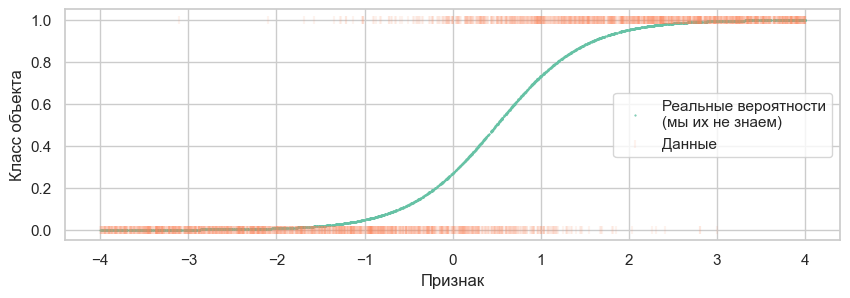

In [4]:
sample_size = 3_000  # Размер выборки

# Признаки
X_train = np.random.uniform(low=-4, high=4, size=(sample_size, 1))

# Таргет
y_mean_true = 1 / (1 + np.exp(1 - 2 * X_train.ravel()))
y_train = np.random.binomial(n=1, p=y_mean_true)

plt.figure(figsize=(10, 3))
plt.scatter(X_train, y_mean_true, marker=".", s=1, label="Реальные вероятности\n(мы их не знаем)")
plt.scatter(X_train, y_train, marker="|", alpha=0.1, label="Данные")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend();

Обучите логистическую регрессию, используя реализацию из `sklearn`, при этом свободный коэффициент должен присутствовать в модели. Укажите также `penalty='none'`.

*Делить данные на обучающую и тестовую части в данном случае не нужно, поскольку цель данной задачи &mdash; посмотреть, как модель представляет исходные данные, а не оценить ее качество.*

In [5]:
LogReg = LogisticRegression(fit_intercept=True ,penalty=None)
LogReg.fit(X_train, y_train)

/Users/vl4dich/vvad/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

Напечатайте оценку коэффициентов из обученной модели

In [6]:
coef = LogReg.coef_.ravel()[0]
inter = LogReg.intercept_[0]

print(f"Коэфицент: {coef:.5f} \nСвободный коэфицент: {inter:.5f}")

Коэфицент: 2.01125 
Свободный коэфицент: -0.86815


Получили коэфиценты очень близкие к тем, с которыми генерировали

Вспомним, обученная модель представляет собой функцию $\widehat{p}: \mathbb{R} \to [0, 1]$, которая для каждого объекта $x \in \mathbb{R}$ возвращает для него оценку вероятности класса 1. Постройте график этой функции.

Ниже объявлена сетка значений  $x \in \mathbb{R}$ для построения графика. На этом же графике:
* постройте предсказания вероятностей класса 1 (бинаризация оценок вероятностей),
* отобразите обучающую выборку.

Похожий график есть в ноутбуке с занятия.

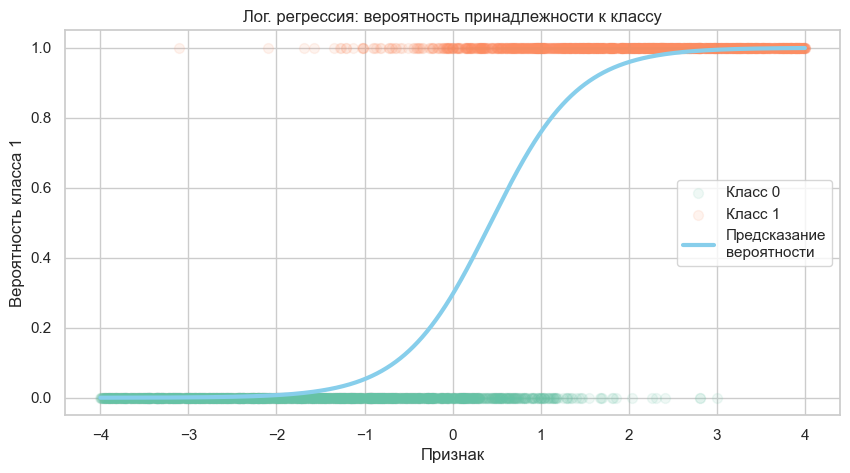

In [7]:
# Создание сетки и предсказаний
X_grid = np.linspace(-4, 4, 10_000).reshape((-1, 1))
probabilities = LogReg.predict_proba(X_grid)[:, 1]

# Отрисовка графика
plt.figure(figsize=(10, 5))
plt.scatter(X_train[y_train == 0], np.zeros_like(X_train[y_train == 0]), s=50, label="Класс 0", alpha=0.1)
plt.scatter(X_train[y_train == 1], np.ones_like(X_train[y_train == 1]), s=50, label="Класс 1", alpha=0.1)
plt.plot(X_grid, probabilities, label="Предсказание\nвероятности", c="skyblue", linewidth=3)
plt.title("Лог. регрессия: вероятность принадлежности к классу")
plt.xlabel("Признак")
plt.ylabel("Вероятность класса 1")
plt.legend()
plt.show()

Разбейте отрезок $[-4, 4]$ на одинаковые бины длины длины 0.2 и для каждого бина посчитайте долю класса 1 среди объектов обучающей выборки, попавших в данный бин. Полученные значения добавьте на график предсказаний вероятностей и сравните эти графики. Проинтерпретируйте полученные результаты.


<details>
<summary> ➡️ Кликни для показа подсказки </summary>
Может помочь <code>np.digitize</code> и метод <code>groupby</code> для таблиц <code>pandas</code>. Рекомендуем посмотреть <a href="https://thetahat.ru/courses/python">обучающие ноутбуки</a> по библиотекам.
</details>

In [8]:
# Обозначаем столбцы
bins = np.linspace(-4, 4, 41)
X_train_bins = np.digitize(X_train, bins).reshape(-1)

# Создание dataframe
df = pd.DataFrame(X_train_bins, columns=['index_bins'])
df['value_bins'] = bins[df['index_bins']] - 0.1
df['y_train'] = pd.Series(y_train.reshape(-1))
agg_df = df.groupby(by='value_bins').agg(func='mean')
agg_df = agg_df.reset_index()

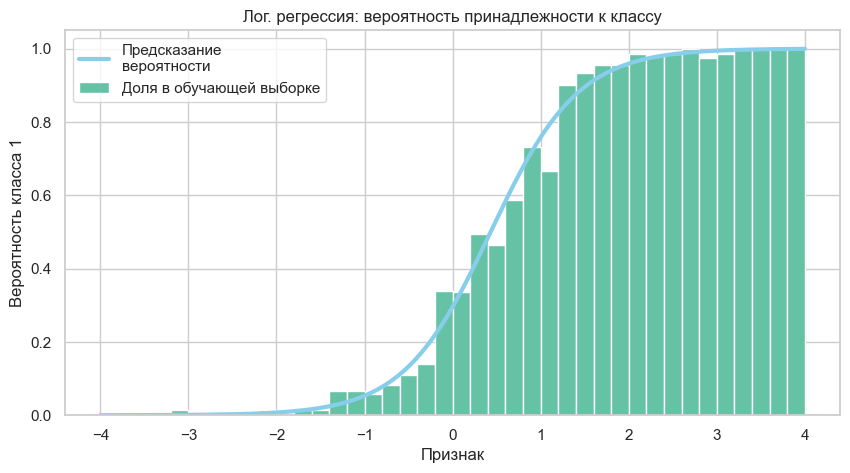

In [9]:
# Строим график
plt.figure(figsize=(10, 5))
plt.plot(X_grid, probabilities, label="Предсказание\nвероятности", c="skyblue", linewidth=3)
plt.bar(agg_df['value_bins'], agg_df['y_train'], width=0.2, label='Доля в обучающей выборке')
plt.title("Лог. регрессия: вероятность принадлежности к классу")
plt.xlabel("Признак")
plt.ylabel("Вероятность класса 1")
plt.legend()
plt.show()

На данных, которые реально распределены по логистической модели модель очень хорошо обучается, причем вероятности реально соответвуют тестовым вероятностям

Также гистограмма намного более информативны, чем сгусток точек, как в первом графике

Повторите проведенное исследование для следующих данных и сравните результаты.

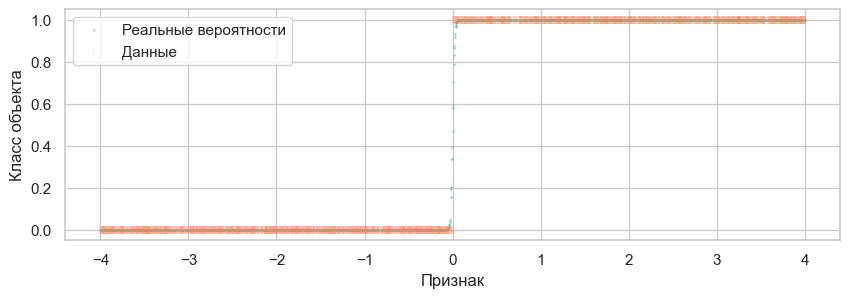

In [10]:
# Признаки
X_train = np.random.uniform(low=-4, high=4, size=(sample_size, 1))

# Таргет
y_mean_true = 1 / (1 + np.exp(-100 * X_train.ravel()))
y_train = np.random.binomial(n=1, p=y_mean_true) 

plt.figure(figsize=(10, 3))
plt.scatter(X_train, y_mean_true, marker=".", s=1, label="Реальные вероятности")
plt.scatter(X_train, y_train, marker="|", alpha=0.1, label="Данные")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend();

In [11]:
LogReg = LogisticRegression(fit_intercept=True ,penalty=None)
LogReg.fit(X_train, y_train)
coef = LogReg.coef_.ravel()[0]
inter = LogReg.intercept_[0]

print(f"Коэфицент: {coef:.5f} \nСвободный коэфицент: {inter:.5f}")

Коэфицент: 54.93154 
Свободный коэфицент: -0.19312


/Users/vl4dich/vvad/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.



Коэфиценты имеют достаточно большую погрешность

In [12]:
probabilities = LogReg.predict_proba(X_grid)[:, 1]
# Обозначаем столбцы
bins = np.linspace(-4, 4, 81)
X_train_bins = np.digitize(X_train, bins).reshape(-1)

# Создание dataframe
df = pd.DataFrame(X_train_bins, columns=['index_bins'])
df['value_bins'] = bins[df['index_bins']] - 0.05
df['y_train'] = pd.Series(y_train.reshape(-1))
agg_df = df.groupby(by='value_bins').agg(func='mean')
agg_df = agg_df.reset_index()

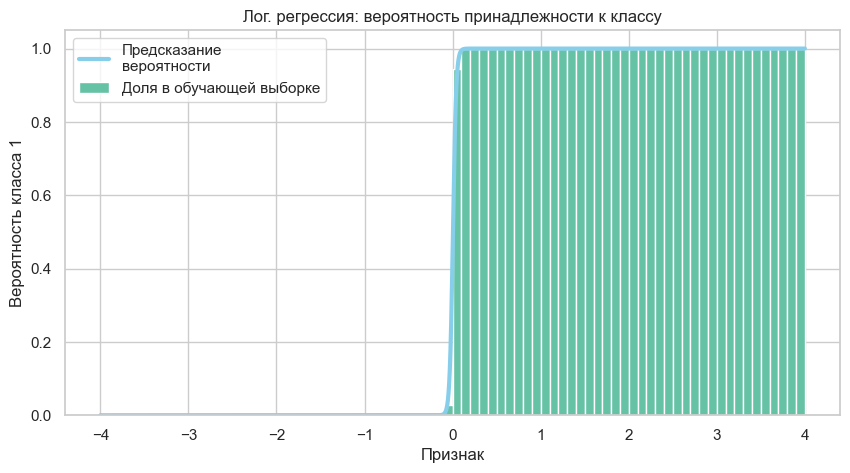

In [13]:
# Строим график
plt.figure(figsize=(10, 5))
plt.plot(X_grid, probabilities, label="Предсказание\nвероятности", c="skyblue", linewidth=3)
plt.bar(agg_df['value_bins'], agg_df['y_train'], width=0.1, label='Доля в обучающей выборке')
plt.title("Лог. регрессия: вероятность принадлежности к классу")
plt.xlabel("Признак")
plt.ylabel("Вероятность класса 1")
plt.legend()
plt.show()

**Выводы:**

В первых данных имеем, что данные отлично подошли под обученную логистическую модель и хорошо ей описываются

Во вторых данных имеем, что модель плохо описывает резкие скачки, потому что логистическая регрессия описывает плавный, можно сказать S-образный переход. Поэтому точки в близи скачка плохо прогнозируются

---
### Задача 2.

Продолжим исследовать модель логистической регрессии. Сгенерируем данные, состоящие из двух бинарных признаков и бинарного таргета

In [14]:
probs = np.random.uniform(size=8)
probs /= probs.sum()
probs

x = np.random.choice(np.arange(8), p=probs, size=10_000)
data = pd.DataFrame(
    np.unpackbits(np.array(x.reshape(-1, 1), dtype=">i8").view(np.uint8), axis=1)[:, -3:],
    columns=["feature_1", "feature_2", "target"],
)
data.head()

,feature_1,feature_2,target
0,1,0,0
1,1,1,1
2,0,0,0
3,1,0,0
4,1,1,0


Особенность таких данных &mdash; конечное число *возможных различных* объектов. В данном случае их всего 4, по количеству всех возможных комбинаций значений признака. Соответственно, любой моделью мы можем сделать только 4 *различных* предсказания вероятности класса 1. Исследуем, как с этим справляется логистическая регрессия.

Сначала для сравнения посчитайте долю класса 1 для каждой категории объектов.

<details>
<summary> ➡️ Кликни для показа подсказки </summary>
    Используйте <code>pd.pivot_table</code>. Рекомендуем посмотреть <a href="https://thetahat.ru/courses/python">обучающие ноутбуки</a> по библиотекам.
</details>

In [15]:
table = pd.pivot_table(
    data, values="target", index=["feature_1"], columns=["feature_2"], aggfunc="mean"
)
table

feature_2,0,1
feature_1,,
0,0.535427,0.331864
1,0.343167,0.597228


Обучите логистическую регрессию с `penalty='none'` и получите предсказания вероятностей для этих четырех типов объектов. Представьте результаты в таком виде, чтобы их удобно было сравнивать с частотами, посчитанными ранее.

In [16]:
# Обучение модели
LogReg_2 = LogisticRegression(penalty=None)
LogReg_2.fit(data[['feature_1', 'feature_2']], data['target'])

# Предсказание
data['pred'] = LogReg_2.predict_proba(data[['feature_1', 'feature_2']])[:, 1]


# Визуализация результатов
table_2 = pd.pivot_table(
    data, values=["pred", "target"], index=["feature_1", "feature_2"], aggfunc="mean"
)
table_2['diff'] = table_2['pred'] - table_2['target']
table_2

/Users/vl4dich/vvad/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.



pred    target      diff
feature_1 feature_2                              
0         0          0.427346  0.535427 -0.108080
          1          0.410775  0.331864  0.078912
1         0          0.504798  0.343167  0.161631
          1          0.487782  0.597228 -0.109446

Почему результаты существенно отличаются?

Для ответа на этот вопрос распишите формулу, которая задает модель логистической регрессии, указав все параметры. Какое предположение о данных при этом делает логистическая регрессия?

$$
\widehat{p}({x}) = \sigma\left(x^T \widehat{\theta}\right) = \frac{1}{1 + \exp\left(-x^T \widehat{\theta}\right)}
$$

Предположение в том, что logit-функция линейная от признаков, то есть в данном случае

$$
\log\left(\frac{p_0}{1-p_0}\right) = \theta_0 + \theta_1  x_1 + \theta_2  x_2
$$

Здесь только 3 степени свободы, т.е.
$$
\text{logit}(1, 1) + \text{logit}(0, 0)= \text{logit}(0, 1) + \text{logit}(1, 0)
$$

Что очевидно может быть неверным






Предложите и реализуйте способ модификации данных так, чтобы логистическая регрессия точнее предсказывала частоты, посчитанные ранее.

<details>
<summary> ➡️ Кликни для показа подсказки </summary>
Подумайте, какое преобразование признаков можно было бы сделать.
</details>

Опишите ваше предложение:

Давайте добавим 4 степень свободы, т. е. добавим признак `'feature_1_and_2'`

Реализация:

In [17]:
# Добавление нового признака
data['feature_1_and_2'] = data['feature_1'] * data['feature_2']

# Обучение модели
LogReg_2 = LogisticRegression(penalty=None)
LogReg_2.fit(data[['feature_1', 'feature_2', 'feature_1_and_2']], data['target'])

# Предсказание
data['pred_adv'] = LogReg_2.predict_proba(data[['feature_1', 'feature_2', 'feature_1_and_2']])[:, 1]


# Визуализация результатов
table_3 = pd.pivot_table(
    data, values=["pred", "pred_adv", "target"], index=["feature_1", "feature_2"], aggfunc="mean"
)
table_3

/Users/vl4dich/vvad/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.



pred  pred_adv    target
feature_1 feature_2                              
0         0          0.427346  0.535442  0.535427
          1          0.410775  0.331839  0.331864
1         0          0.504798  0.343159  0.343167
          1          0.487782  0.597261  0.597228

<font color="green" size="5"><b>Исправления ниже</b></font>


**Выводы:**

Модель линейной регрессии требует, чтобы логит-функция была линейной в зависимости от признаков, если зависимость сильно не линейная, то предсказательная сила сильно падает. Для того, чтобы зависимость стала линейная, то нужно добавить новые признаки. Самое главное, что мы получили это при достаточном кол-ве признаков модель логистической регрессии выдает не смещенные оценки вероятности, то есть она не занижает и не завышает их. То есть вероятность класса 1 (при конкретном входе признаков) в логистической регрессии стремиться к вероятности класса 1 в изначальной выборке (при том же конкретном входе признаков). Это отличный результат 

<font color="green" size="5"><b>Исправления выше</b></font>


---
### Задача 3.

*Не все в жизни ограничивается двумя классами, бывает и многоклассовый случай.*

Рассмотрим модель логистической регрессии для случая многоклассовой классификации. Пусть метка класса принимает значения в $K$-элементном множестве $\mathscr{Y} = \{1, ..., K\}$. Параметры модели $\theta$ являются матрицей размерности $K \times d$, где $d$ &mdash; количество признаков. 

Введем soft-max функцию: 
$$
\sigma(z) = \big( \sigma_1(z), \dots, \sigma_K(z) \big) = \left( \frac{e^{z_1}}{\sum_{i=1}^K e^{z_i}}, \dots, \frac{e^{z_K}}{\sum_{i=1}^K e^{z_i}} \right).
$$

Из определения ясно, что $\sum\limits_{k=1}^K \sigma_k(z) = 1$. Название функции связано с тем, что самая большая компонента вектора $z$ будет близка к $1$, а все остальные будут малы, но не равны нулю. Таким образом, происходит сглаженное взятие `argmax`.

По аналогии с простой логистической регрессией рассмотрим выборку объектов $x_1, ...,  x_n$, где $x_i = (x_{i1}, \dots, x_{id})^T \in \mathbb{R}^d$, и выборку таргетов $Y_1, ...,  Y_n \in \mathscr{Y}$
Модель логистической регрессии в многоклассовом случае предполагает, что $\mathsf{P}_{\theta}(Y_{i} = k) = \sigma_k(\theta x)$, где $\theta \in \mathbb{R}^{k \times d}$. Тогда обучение модели логистической регрессии в многоклассовом случае выглядит следующим образом:

$$
- \sum_{i=1}^n \sum_{k=1}^K I\{Y_i = k\} \log
    \sigma_k(\theta x_i)
\longrightarrow \min_{\theta}
$$


**1.** Определите множество моделей $\mathcal{M}$, соответствующее логистической регрессии.

$$
\mathcal{M}
=
\left\{
P:\mathbb{R}^d \to [0,1]^K
\;\middle|\;
P(y=k \mid x)=\sigma_k(\theta x),\;
\theta \in \mathbb{R}^{K \times d}
\right\}.
$$

**2.** Выпишите формулы GD и SGD для максимизации этой функции правдоподобия. В формулу нужно упростить подобно тому, как было показано на занятии для бинарной классификации.

Рассмотрим функцию потерь
$$
L = \frac{1}{n}\sum_{i=1}^{n} L_i,
$$
где
$$
L_i = -\sum_{k=1}^{K} I\{y_i = k\}\,\log \sigma_k(\Theta x_i),
$$
где
$$
\sigma_k(z_i) = \frac{e^{z_{ik}}}{\sum_{j=1}^{K} e^{z_{ij}}}.
$$

Обозначим
$$
\theta x_i = z_i,
$$
тогда
$$
L_i = -\sum_{k=1}^{K} I\{y_i = k\}
\left(
z_{ik} - \log \sum_{j=1}^{K} e^{z_{ij}}
\right).
$$

Пусть
$$
y_i =
\begin{pmatrix}
0\\
0\\
\vdots\\
1\\
0\\
\vdots\\
0
\end{pmatrix},
\qquad y_{ik} = 1.
$$

Найдём:
$$
\frac{\partial L_i}{\partial z_{ik}}
=
-y_{ik}
+
\left(
\sum_{k'=1}^{K} y_{ik}\,\log \sum_{j=1}^{K} e^{z_{ij}}
\right)'_{z_{ik}}.
$$

$$
\sum_{k=1}^{K} y_{ik} = 1.
$$

Тогда
$$
\frac{\partial L_i}{\partial z_{ik}}
=
-y_{ik}
+
\left(
\log \sum_{j=1}^{K} e^{z_{ij}}
\right)'_{z_{ik}}
=
-y_{ik}
+
\frac{e^{z_{ik}}}{\sum_{j=1}^{K} e^{z_{ij}}}
=
-y_{ik} + \sigma_k(z_i).
$$

$$
z_i = \theta x_i,
$$

$$
z_{ik} = \theta_k x_i.
$$

Воспользуемся цепным правилом

$$
\frac{\partial L_i}{\partial z_{ik}} \cdot \frac{\partial z_{ik}}{\partial \theta_k}
=
\left(-y_{ik} + \sigma_k(z_i)\right)\cdot x_i^{T}.
$$

$$
\nabla L_i = \left(-y_i + \sigma(z_i)\right)\cdot x_i^{T}.
$$

$$
\nabla L = \sum_{i=1}^{n} \nabla L_i
=
\sum_{i=1}^{n}
\left(-y_i + \sigma(\theta x_i)\right)\cdot x_i^{T}.
$$

Шаг градиентного спуска:
$$
\theta_{t+1}
= \theta_t
- \eta \sum_{i=1}^{n}
\left(-y_i + \sigma(\theta x_i)\right)\cdot x_i^{T}.
$$

Шаг стохастического градиентного спуска:

$$
\theta_{t+1}
= \theta_t
- \frac{\eta}{b} \sum_{i \in Batch_t}^{}
\left(-y_i + \sigma(\theta x_i)\right)\cdot x_i^{T}.
$$

Каждый элемент $Batch_t$ равновероятно любой индекс от $1$ до $n$
Размер батча равен $b$


---
### Задача 4.

*Устали писать формулы? Самое время что-то закодить!*

*Обрати внимание, что выполнение это задачи требуется для полноценного решения следующей. Тем не менее, если ты не хочешь кодить, можно сразу переходить к следующей задаче и выполнить то, что получится выполнить с помощью готовых инструментов. В таком случае можно получить частичные баллы за следующую задачу.*


**1.** Реализуйте логистическую регрессию для двух вариантов поиска оценки параметров:
* простой градиентный спуск;
* стохастический градиентный спуск с `batch_size` элементами на каждой итерации.

Останавливайте итерации при выполнении хотя бы одного из двух условий:
* количество итераций превзошло число `max_iter`;
* оптимизируемый функционал изменился за итерацию не более чем на `tol`.

Если указан параметр `save_history`, после выполнения каждой итерации с целью дальнейшего анализа в поле `self.history` сохраняйте 
* время, прошедшее с момента начала обучения
* значение оптимизируемого функционала:
    * полная кросс-энтропия для случая простого градиентного спуска
    * оценка кросс-энтропии для случая стохастического градиентного спуска, оценка должна быть произведена по тому же батчу объектов, который использовался для выполнения шага обучения.

*Замечания.*

1. Время измеряйте с помощью `from time import time`.

2. Иногда при подсчете сигмоиды и оптимизируемого функционала могут возникать вычислительные ошибки. Для их избежания существуют специальные трюки.
    * [How to Evaluate the Logistic Loss and not NaN trying](http://fa.bianp.net/blog/2019/evaluate_logistic/)
    * [Exp-normalize trick](https://timvieira.github.io/blog/post/2014/02/11/exp-normalize-trick/)<br>
3. Трюки не обязательно реализовывать самостоятельно, можете воспользоваться функциями для них из `numpy` или `scipy`:
    * [`numpy.logaddexp`](https://numpy.org/doc/stable/reference/generated/numpy.logaddexp.html);
    * [`scipy.special.logsumexp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.logsumexp.html).
4. Обратите внимание, что класс `MyLogisticRegression` &mdash; наследник класса `BaseEstimator`, это с легкостью позволит использовать наш класс в различных пайплайнах библиотеки `sklearn`.
4. Следите за качеством кода, комментируйте логические этапы кода. Несоблюдение этого требования может привести к потере баллов.


**При реализации класса запрещено пользоваться ИИ-инструментами.**


In [18]:
# При реализации класса запрещено пользоваться ИИ-инструментами.


class MyLogisticRegression(BaseEstimator):
    """Модель логистической регрессии.

    Параметры:
    method (Literal['gd', 'sgd']): Метод оптимизации ('gd' - градиентный спуск,
        'sgd' - стохастический градиентный спуск).
    learning_rate (float): Константа скорости обучения, на которую домножаем градиент при обучении
    tol (float): Допустимое изменение функционала между итерациями.
    max_iter (int): Максимальное число итераций.
    batch_size (int): Размер выборки для оценки градиента (используется только при 'sgd').
    fit_intercept (bool): Добавлять ли константу в признаки.
    save_history (bool): Сохранять ли историю обучения.
    """

    def __init__(
        self,
        method: Literal["gd", "sgd"] = "gd",
        learning_rate: float = 0.01,
        tol: float = 1e-3,
        max_iter: int = int(1e4),
        batch_size: int = 64,
        fit_intercept: bool = True,
        save_history: bool = True,
    ):
        """Создает модель и инициализирует параметры."""
        self.method = method
        self.learning_rate = learning_rate
        self.tol = tol
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.fit_intercept = fit_intercept
        self.save_history = save_history
        self.history = {"Loss": [], "Time": []}

    @staticmethod
    def _sigmoid(x: np.ndarray) -> np.ndarray:
        """Вычисляет сигмоидную функцию."""
        return expit(x)

    def _add_intercept(self, X: np.ndarray) -> np.ndarray:
        """Добавляет свободный коэффициент к матрице признаков.

        Параметры: X (np.ndarray): Исходная матрица признаков.

        Возвращает: np.ndarray: Матрица X с добавленным свободным
        коэффициентом.
        """
        X_copy = np.full((X.shape[0], X.shape[1] + 1), fill_value=1)
        X_copy[:, :-1] = X
        return X_copy

    def fit(self, X: np.ndarray, Y: np.ndarray) -> "MyLogisticRegression":
        """Обучает модель логистической регрессии.

        Также, в случае self.save_history=True, добавляет в self.history
        текущее значение оптимизируемого функционала и затраченное время.

        Параметры:
        X (np.ndarray): Матрица признаков.
        Y (np.ndarray): Вектор истинных меток.

        Возвращает:
        LogisticRegression: Обученная модель.
        """
        if X.shape[0] != Y.shape[0]:
            raise ValueError("Количество строк в X и Y должно совпадать")

        if self.fit_intercept:
            X_copy = self._add_intercept(X)
        else:
            X_copy = X.copy()
            
        if self.save_history:
            self.history = {"Loss": [], "Time": []}
            
        self.n_iter_ = 0
        self.coef_ = np.zeros(X_copy.shape[1])
        time_start = time()
        n = X.shape[0]
        
        if self.method == "gd":
            z = X_copy @ self.coef_
            Loss = - (Y @ -np.logaddexp(0, -z) + (1 - Y) @ -np.logaddexp(0, z)) / n
            for i in range(self.max_iter):
                self.n_iter_ += 1
                grad = X_copy.T @ (self._sigmoid(X_copy @ self.coef_) - Y) / n
                self.coef_ -= grad * self.learning_rate
                z = X_copy @ self.coef_
                new_Loss = - (Y @ -np.logaddexp(0, -z) + (1 - Y) @ -np.logaddexp(0, z)) / n
                if self.save_history:
                    self.history['Loss'].append(new_Loss)
                    self.history['Time'].append(time() - time_start)
                if abs(Loss - new_Loss) < self.tol:
                    break
                else:
                    Loss = new_Loss
                    
            
        if self.method == "sgd":
            Y_copy = Y.to_numpy()
            for i in range(self.max_iter):
                indexes = np.random.choice(X_copy.shape[0], size=self.batch_size, replace=True)
                X_batch = X_copy[indexes]
                Y_batch = Y_copy[indexes]
                z = X_batch @ self.coef_
                Loss = - (Y_batch @ -np.logaddexp(0, -z) + (1 - Y_batch) @ -np.logaddexp(0, z)) / self.batch_size
                self.n_iter_ += 1
                grad = (X_batch.T @ (self._sigmoid(z) - Y_batch)) / self.batch_size
                self.coef_ -= grad * self.learning_rate
                z = X_batch @ self.coef_
                new_Loss = - (Y_batch @ -np.logaddexp(0, -z) + (1 - Y_batch) @ -np.logaddexp(0, z)) / self.batch_size
                if self.save_history:
                    self.history['Loss'].append(new_Loss)
                    self.history['Time'].append(time() - time_start)
                if abs(Loss - new_Loss) < self.tol:
                    break
            
            
            
        self.intercept_ = 0.0
        if self.fit_intercept:
            self.intercept_ = self.coef_[-1]
            self.coef_ = self.coef_[:-1]
            
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Возвращает вероятности классов 0 и 1.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Матрица вероятностей классов (n_samples, 2).
        """

        if X.shape[1] != self.coef_.shape[0]:
            raise ValueError("Число признаков в X не соответствует числу коэффициентов модели")
            
        if self.fit_intercept:
            X_copy = self._add_intercept(X)
            coef_temp = np.append(self.coef_, self.intercept_)
            prob_predictions = self._sigmoid(X_copy @ coef_temp)
        else:
            X_copy = X.copy()
            prob_predictions = self._sigmoid(X_copy @ self.coef_)
    
    
        prob_predictions = np.column_stack((1 - prob_predictions, prob_predictions))
        
        return prob_predictions

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Возвращает предсказанные классы.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Предсказанные классы.
        """

        predictions = (self.predict_proba(X)[:, 1] >= 0.5).astype(int)
        
        return predictions

---
### Задача 5.

*Наконец, пришло время по полной насладиться логистической регрессией, и мы вам в этом поможем! В этой задаче  тебя ждет увлекательное исследование с реальными данными. Чтобы было интереснее, мы предоставляем возможность выбрать один из двух датасетов.*

*Для полноценного решения задачи требуется правильно решить предыдущую задачу. Без решения предыдущей задачи можно решать эту задачу с помощью готовых инструментов. В таком случае не получится решить все пункты задачи, соответственно, баллы за задачу будут частичными.*

Выберите один из следующих датасетов, с которым вы будете работать в этой задаче.

**A. Diabetes Health Indicators**

<details>
<summary> ➡️ Описание датасета </summary>    

<a href="https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset"><b>Ссылка</b></a>

**!!! Для данного задания будем рассматривать версию датасета** `diabetes_binary_5050split_health_indicators_BRFSS2015.csv`


Этот датасет содержит статистику здравоохранения и информацию об образе жизни, полученную в результате опросов вместе с меткой наличия/отсутствия диабета у участников. Среди признаков есть демографические данные, результаты лабораторных тестов и ответы на вопросы анкеты. Целевая переменная  `Diabetes_binary` определяет статус пациента: есть ли у него диабет или предиабет (`1`), или он здоров (`0`).
    
Приведем описание некоторых признаков, представленных в датасете.

**Показатели здоровья**

- `HighBP`: Высокое кровяное давление (`1` = да, `0` = нет).

- `HighChol`: Высокий уровень холестерина (`1` = да, `0` = нет).

- `CholCheck`: Проверка уровня холестерина за последние 5 лет (`1` = да, `0` = нет).

- `BMI`: Индекс массы тела (рассчитывается как вес (кг) / рост² (м²)).

- `GenHlth`: Общая оценка здоровья (`1` = отличное, `2` = очень хорошее, ..., `5` = плохое).

**Образ жизни**
- `Smoker`: Статус курения (`1` = выкурил ≥100 сигарет за жизнь, `0` = нет).

- `PhysActivity`: Физическая активность вне работы (`1` = да, `0` = нет).

- `Fruits`: Регулярное употребление фруктов (`1` = не менее 1 раз в день, `0` = реже).

**Доступ к медицине**
- `AnyHealthcare`: Наличие медицинской страховки (`1` = да, `0` = нет).

- `NoDocbcCost`: Отказ от визита к врачу из-за стоимости (`1` = да, `0` = нет).

Для выполнения задачи используйте все имеющиеся признаки, не ограничиваясь представленными выше.
</details>

**B. Predicting Pulsar Star**

<details>
<summary> ➡️ Описание датасета </summary>    

<a href="https://www.kaggle.com/colearninglounge/predicting-pulsar-starintermediate"><b>Ссылка</b></a>
    
Пульсары &mdash; это космические объекты, излучающие в различных диапазонах длин волн. Согласно современным астрофизическим данным, пульсары представляют собой вращающиеся нейтронные звезды, обладающие магнитным полем, наклоненным относительно оси вращения.

В используемом датасете есть как примеры ложных обнаружений, так и примеры реальных пульсаров, подтвержденные учеными. Данные получены в результате [The High Time Resolution Universe Pulsar Survey I](https://arxiv.org/abs/1006.5744).
    
Приведем описание некоторых признаков, представленных в датасете.
    

* **Mean of the integrated profile**: Среднее значение интегрированного по времени профиля. Иначе говоря, берём длинную запись сигнала, разрезаем её на куски по предполагаемому периоду пульсара, складываем эти куски и получаем типичную «среднюю» кривую яркости за один период. Признак характеризует среднюю яркость звезды

* **Standard deviation of the integrated profile**: Стандартное отклонение интегрированного профиля, характеризует меру разброса между минимальной и максимальной яркостью.

* **Excess kurtosis of the integrated profile**: Эксцесс интегрированного профиля, показывает, насколько "тяжёлые" хвосты распределения интегрированного профиля по сравнению с нормальным распределением. Положительный эксцесс указывает на более острый пик и тяжёлые хвосты. Вычисляется по формуле
$$\gamma = \frac{1}{\sigma^4} \mathsf{E}(X - a)^4 - 3,$$
где $a = \mathsf{E}X$, $\sigma = \mathsf{E}(X-a)^2$. При этом мы вычитаем 3, чтобы нормального распределения было 0


* **Skewness of the integrated profile**: Асимметрия интегрированного профиля, мера асимметрии распределения интегрированного профиля. Отрицательное значение указывает на левостороннюю асимметрию, положительное — на правостороннюю. Вычисляется по формуле
$$\kappa = \frac{1}{\sigma^3} \mathsf{E}(X - a)^3,$$
где $a = \mathsf{E}X$, $\sigma = \mathsf{E}(X-a)^2$. Если $\kappa > 0$, то правый хвост распределения более тяжёлый, чем левый, иначе говоря, распределение имеет больше крупных значений.

* **Mean of the DM-SNR curve**: Среднее значение кривой DM-SNR, среднее значение кривой, связанной с отношением сигнал-шум (SNR) и дисперсионной мерой (DM). DM характеризует задержку сигнала на разных частотах из-за межзвёздной среды.

* **Standard deviation of the DM-SNR curve**: Стандартное отклонение кривой DM-SNR, мера разброса значений кривой DM-SNR.

* **Excess kurtosis of the DM-SNR curve**: Эксцесс кривой DM-SNR, показывает, насколько "тяжёлые" хвосты распределения кривой DM-SNR по сравнению с нормальным распределением.

* **Skewness of the DM-SNR curve**: Асимметрия кривой DM-SNR, мера асимметрии распределения кривой DM-SNR.

* **target_class**: Целевой класс, бинарная метка, указывающая, является ли объект пульсаром (1) или ложным обнаружением (0). В предоставленном ниже фрагменте все примеры имеют метку 0, что означает, что это ложные обнаружения.
    
    
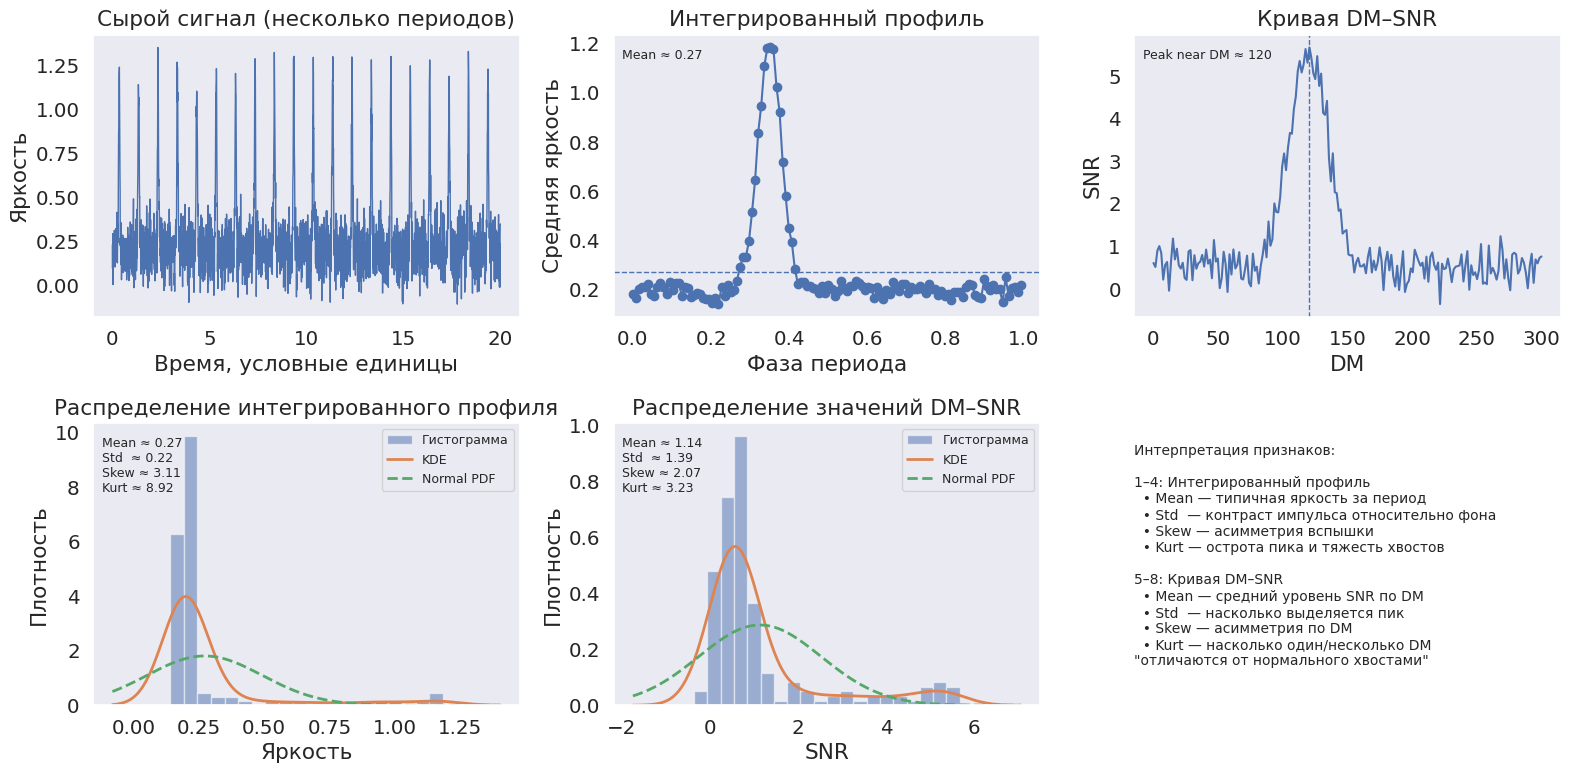
    
    
    

</details>

Укажите, какой датасет выберите:

**A. Diabetes Health Indicators**

Скачайте файл и прочитайте его с помощью `pandas`.

In [19]:
dataset = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
dataset.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


Разделите выборку на обучающую и тестовую

In [20]:
y = dataset['Diabetes_binary']
X = dataset.drop(columns='Diabetes_binary')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=847)

**1.** Исследуйте данные на предмет количества объектов и признаков, типа признаков, наличия пропусков.

In [21]:
print(f'Количество объектов {dataset.shape[0]}')
print(f'Количество признаков {X_train.shape[1]}')

Количество объектов 70692
Количество признаков 21


In [22]:
X_train.isna().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Пропусков не оказалось, значит не придется их заполнять

Выполните необходимую обработку признаков. Используйте для этого конструкции `ColumnTransformer`, `Pipeline` и подобные.

Все признаки бинарные, кроме:
* `BMI, MentHlth, PhysHlth` - числовые
* `GenHlth, Age, Education, Income` - категориальные, но с порядком, так что их оставим без изменений
* Остальные категориальные бинарные

In [23]:
scaler = StandardScaler()

X_train_processed = scaler.fit_transform(X_train)
X_test_processed = scaler.transform(X_test)

**2.** Обучите две модели логистической регрессии с помощью методов
* простой градиентный спуск;
* стохастический градиентный спуск.

In [24]:
model1 = MyLogisticRegression(method='gd', learning_rate=0.01, max_iter=3000, tol=1e-6)

model1.fit(X_train_processed, y_train)

,method,'gd'
,learning_rate,0.01
,tol,1e-06
,max_iter,3000
,batch_size,64
,fit_intercept,True
,save_history,True


In [25]:
model2 = MyLogisticRegression(method='sgd', learning_rate=0.01, batch_size=3000, max_iter=3000, tol=1e-6)

model2.fit(X_train_processed, y_train)

,method,'sgd'
,learning_rate,0.01
,tol,1e-06
,max_iter,3000
,batch_size,3000
,fit_intercept,True
,save_history,True


Постройте график, на котором нанесите две кривые обучения, каждая из которых отображает зависимость оптимизируемого функционала от номера итерации метода. Нарисуйте также график зависимости этого функционала от времени работы метода. 

*Замечания:*
* Все графики должны быть информативны, с подписанными осями и т.д..
* Для чистоты эксперимента желательно не запускать в момент обучения другие задачи.

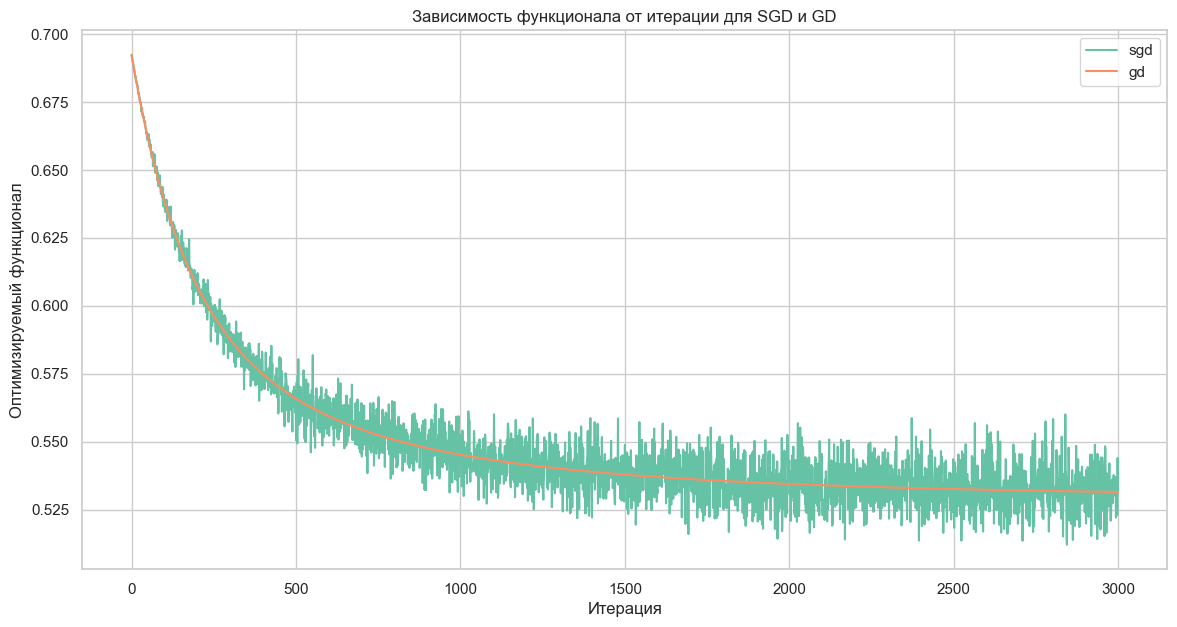

In [26]:
plt.figure(figsize=(14,7))
plt.plot(model2.history['Loss'], label='sgd')
plt.plot(model1.history['Loss'], label='gd')
plt.xlabel('Итерация')
plt.ylabel('Оптимизируемый функционал')
plt.title('Зависимость функционала от итерации для SGD и GD')
plt.legend()
plt.show()

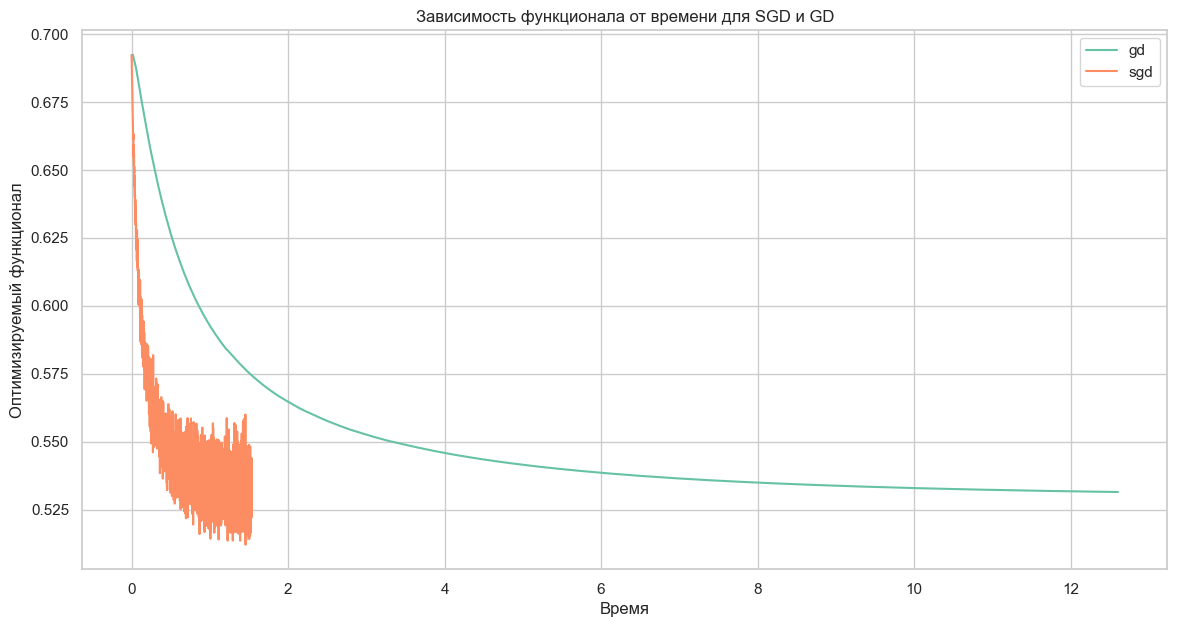

In [27]:
plt.figure(figsize=(14,7))
plt.plot(model1.history['Time'], model1.history['Loss'], label='gd')
plt.plot(model2.history['Time'], model2.history['Loss'], label='sgd')
plt.xlabel('Время')
plt.ylabel('Оптимизируемый функционал')
plt.title('Зависимость функционала от времени для SGD и GD')
plt.legend()
plt.show()

Сделайте выводы. Что будет при обучении на датасете, если  увеличить количество объектов, а число признаков оставить прежним?

<font color="green" size="5"><b>Исправления ниже</b></font>


Время обучения GD сильно зависит от кол-во объектов (нужно пройтись по всем объектам). Так как длина батча в SGD фиксирована, то одна итерация SGD не станет дольше. То есть более оптимально выбирать SGD для датасетов с большим кол-вом объектов.

<font color="green" size="5"><b>Исправления выше</b></font>


**3.** Исследуйте влияние размер шага (`learning_rate`) на качество модели для двух режимов обучения (простой и стохастический градиентный спуск). Для каждого размера шага получите качество модели при использовании простого и стохастического градиентного спуска. Сравните качество полученных моделей по метрике `accuracy`.

<font color="green" size="5"><b>Исправления ниже</b></font>


In [53]:
learning_rate_list = np.logspace(-5, 3, 8)

results = []
histories_gd = []
histories_sgd = []
histories_gd_coefs = []
histories_sgd_coefs = []

results_rate = pd.DataFrame(learning_rate_list)

for rate in learning_rate_list:
    model1 = MyLogisticRegression(method='gd', learning_rate=rate, max_iter=6000, tol=3 * (1e-6))
    time_gd = -time()
    model1.fit(X_train_processed, y_train)
    time_gd += time()
    model2 = MyLogisticRegression(method='sgd', learning_rate=rate, batch_size=4096, max_iter=6000, tol=3 * (1e-5))
    time_sgd = -time()
    model2.fit(X_train_processed, y_train)
    time_sgd += time()
    results.append({'rate': rate, 
                   'acc_gd': (model1.predict(X_test_processed) == y_test).sum() / y_test.shape[0],
                   'acc_sgd': (model2.predict(X_test_processed) == y_test).sum() / y_test.shape[0],
                   'time_gd': time_gd,
                   'time_sgd': time_sgd,
                   'iter_gd': len(model1.history['Loss']),
                   'iter_sgd': len(model2.history['Loss'])})
    histories_gd.append(model1.history['Loss'])
    histories_sgd.append(model2.history['Loss'])
    histories_gd_coefs.append(model1.coef_)
    histories_sgd_coefs.append(model2.coef_)
    
results = pd.DataFrame(results)
results

,rate,acc_gd,acc_sgd,time_gd,time_sgd,iter_gd,iter_sgd
0,0.000010,0.706344,0.704576,0.034811,0.004439,1,1
1,0.000139,0.708749,0.705000,21.814696,0.001282,6000,1
2,0.001931,0.720419,0.710517,25.784130,0.721557,6000,1333
3,0.026827,0.724096,0.720702,5.613326,0.297882,1282,480
4,0.372759,0.725865,0.726148,0.853268,3.057304,194,4917
5,5.179475,0.656977,0.687885,23.317003,0.232638,6000,329
6,71.968567,0.694533,0.700969,23.755120,2.535479,6000,4422
7,1000.000000,0.692128,0.701393,20.996311,3.104176,6000,6000


<font color="green" size="5"><b>Исправления выше</b></font>


<font color="green" size="5"><b>Исправления ниже</b></font>


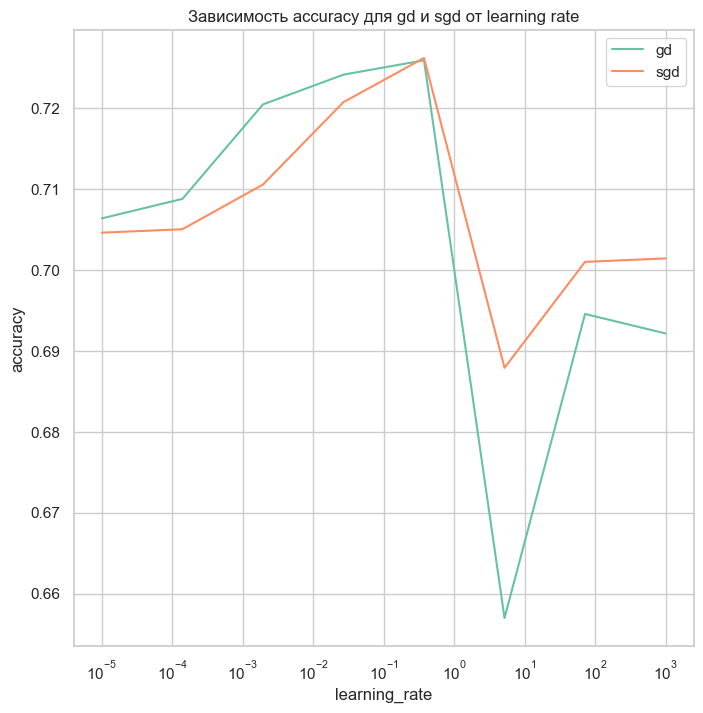

In [54]:
plt.figure(figsize=(8,8))
plt.plot(results['rate'], results['acc_gd'], label='gd')
plt.plot(results['rate'], results['acc_sgd'], label='sgd')
plt.xscale('log')
plt.xlabel('learning_rate')
plt.ylabel('accuracy')
plt.legend()
plt.title('Зависимость accuracy для gd и sgd от learning rate')

plt.show()

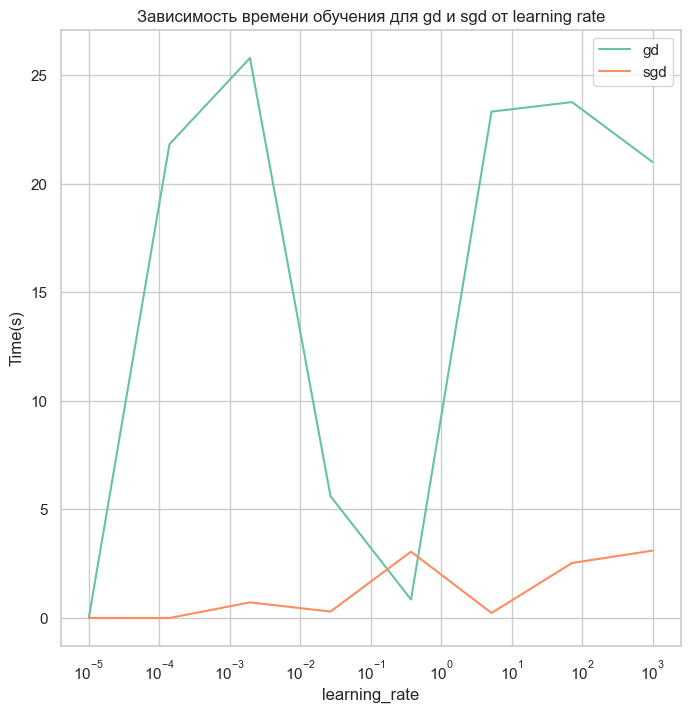

In [55]:
plt.figure(figsize=(8,8))
plt.plot(results['rate'], results['time_gd'], label='gd')
plt.plot(results['rate'], results['time_sgd'], label='sgd')
plt.xscale('log')
plt.xlabel('learning_rate')
plt.ylabel('Time(s)')
plt.legend()
plt.title('Зависимость времени обучения для gd и sgd от learning rate')

plt.show()

<font color="green" size="5"><b>Исправления выше</b></font>


Сделайте выводы

`acc_gd` и `acc_sgd` Возрастают до своего пика `0.725`.  При больших `rate`, `acc` падает

Пик при `rate = 0.372759`


Постройте кривые обучения для различных `learning_rate`. Не обязательно рассматривать все `learning_rate`, так как их слишком много, и график будет нагроможден. Возьмите около половины из них.

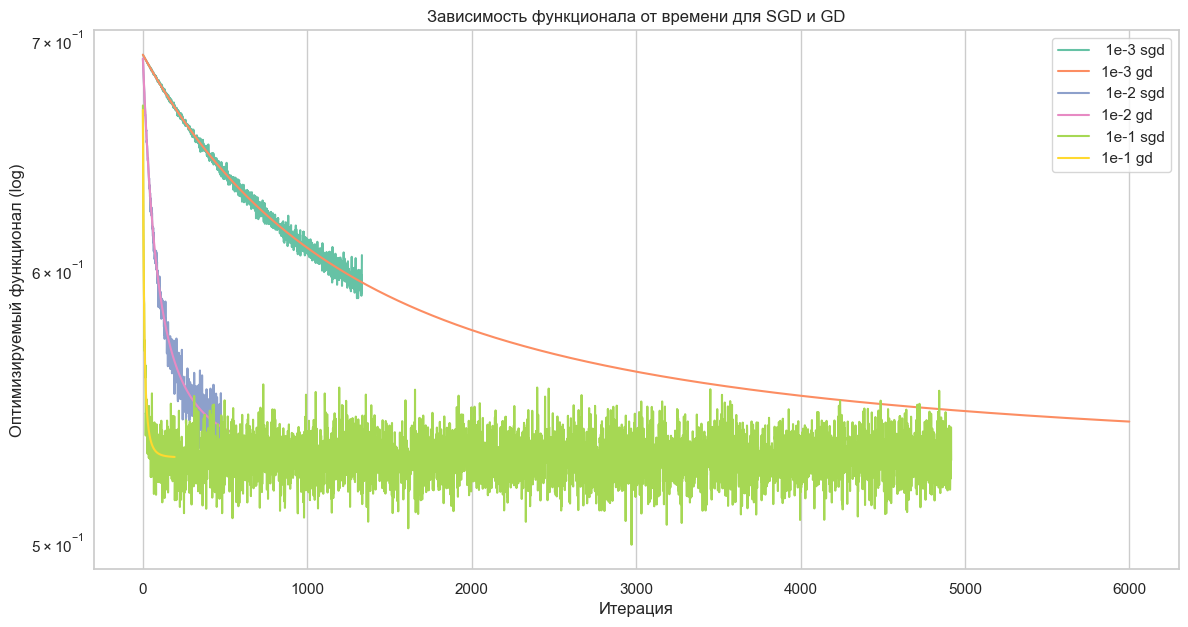

In [56]:
plt.figure(figsize=(14,7))
for i in range(2, 5):
    plt.plot(histories_sgd[i], label=f' 1e{-5 + i} sgd')
    plt.plot(histories_gd[i], label=f'1e{-5 + i} gd')
plt.xlabel('Итерация')
plt.ylabel('Оптимизируемый функционал (log)')
plt.yscale('log')
plt.title('Зависимость функционала от времени для SGD и GD')
plt.legend()
plt.show()

Какой `learning_rate` стоит выбирать в зависимости от способа обучения модели? Чем плохи маленькие и большие `learning_rate`?

В нашей модели и для sgd и для gd наибольшую точность дает значение `learning_rate`, равное $0.37$ 

При очень маленьких `learning_rate` шаги в градиентном спуске слишком маленькие, поэтому модель не успевает дойти до своего оптимума

При очень больших `learning_rate` шаги становятся слишком большими и функция начинает колебаться, создается большой шум

Характер зависимости для sgd и для gd очень близкий пики немного смещены из-за произвольности batch в sgd

**4.** Рассмотрите наилучшую модель с предыдущего шага. Визуализируйте значения полученных оценок коэффициентов.

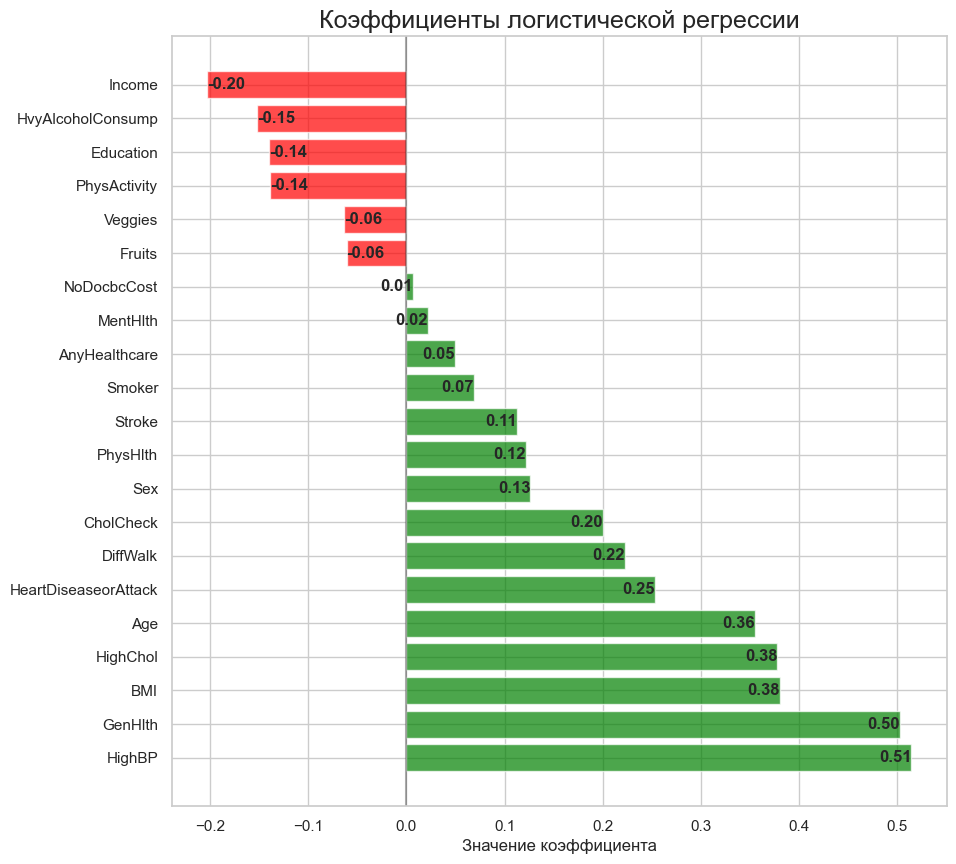

In [57]:
coef = histories_gd_coefs[2]
feature = X_train.columns

coef_plot_df = pd.DataFrame(
    {"Признак": feature, "Коэффициент": coef}).sort_values("Коэффициент", ascending=False)

plt.figure(figsize=(10, 10))

# Верхний график — коэффициенты
colors = ["green" if x > 0 else "red" for x in coef_plot_df["Коэффициент"]]
plt.barh(coef_plot_df["Признак"], coef_plot_df["Коэффициент"], color=colors, alpha=0.7)
plt.xlabel("Значение коэффициента")
plt.title("Коэффициенты логистической регрессии", fontsize=18)
plt.axvline(x=0, color="black", linestyle="-", alpha=0.3)
plt.tick_params(axis="y")
plt.tick_params(axis="x")

for coef_index, coef in enumerate(coef_plot_df["Коэффициент"]):
    plt.text(
        coef,
        coef_index,
        f"{coef:.2f}",
        va="center",
        ha="right" if coef > 0 else "left",
        fontweight="bold",
    )

Сравните данную модель с бейзлайном, который в качестве предсказания выдает самый частый класс на обучающей выборке.

In [58]:
most_pop = np.round(y_train.mean())

print(f'Точность Бейзлайна: {(most_pop == y_test).mean():.3f}')

Точность Бейзлайна: 0.498


Насколько хорошее получилось качество обученной модели?

Точность оказалась сильно выше, чем точность бейзлайн модели. Наша модель имеет предсказательную силу.
$0.725 > 0.498$

**5.** Исследуйте логит на линейность по некоторым из признаков.

In [59]:
def kernel_smooth_logit(
    x: np.ndarray, y: np.ndarray, x_grid: np.ndarray, h: float = 1.0, epsilon: float = 1e-10
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Вычисляет сглаженный логит с помощью ядерного сглаживания.

    Параметры:
    x : np.ndarray, shape (n_samples,)
        Значения признака для вычисления сглаживания.
    y : np.ndarray, shape (n_samples,)
        Целевые переменные (должны содержать 0 и 1).
    x_grid : np.ndarray, shape (n_points,)
        Сетка точек, в которых вычисляется оценка логита.
    h : float, default=1.0
        Ширина ядра (bandwidth) для сглаживания.
    epsilon : float, default=1e-10
        Малое число для регуляризации и избежания численной нестабильности.

    Возвращает:
    x_grid : np.ndarray
        Исходная сетка точек (возвращается для удобства).
    logit_smoothed : np.ndarray
        Сглаженные значения логита в точках сетки.
    """
    # Гауссовское ядро
    kernel = sps.norm(scale=h)

    # Вычисляем значения ядра
    kernel_values = kernel.pdf(x[:, np.newaxis] - x_grid[np.newaxis, :])

    # Ядерная оценка вероятности P(y=1|x)
    numerator = (y[:, np.newaxis] * kernel_values).sum(axis=0)
    denominator = kernel_values.sum(axis=0)

    # Избегаем деления на ноль
    denominator = np.maximum(denominator, epsilon)
    y_est = numerator / denominator

    # Регуляризация для избежания крайних значений
    y_est = np.clip(y_est, epsilon, 1 - epsilon)

    # Преобразование в логит: log(P/(1-P))
    logit_smoothed = np.log(y_est / (1 - y_est))

    return x_grid, logit_smoothed


def plot_logit_linearity_check(
    X: np.ndarray,
    y: Union[np.ndarray, list],
    list_of_features : List,
    h: float = 1.0,
    size: Optional[int] = 5000,
    use_percentiles: bool = True,
    figsize: Tuple[int, int] = (12, 4),
    n_rows: int = 1
) -> None:
    """
    Визуальная проверка линейности логита для всех признаков.

    Параметры:
    X : np.ndarray, shape (n_samples, n_features)
        Матрица признаков данных.
    y : Union[np.ndarray, list], shape (n_samples,)
        Вектор меток классов (0 и 1).
    list_of_features : List
        Список признаков для подписи графика.
    h : float, default=1.0
        Ширина ядра для сглаживания.
    size : Optional[int], default=5000
        Размер подвыборки для ускорения вычислений. Если None, используется вся выборка.
    use_percentiles : bool, default=True
        Если True, использует 5-й и 95-й процентили для построения сетки (устойчиво к выбросам).
        Если False, использует минимум и максимум.
    figsize : Tuple[int, int], default=(12, 4)
        Размер фигуры для отображения графиков.
    n_rows: int, default=1
        Количество строк для отображения матрицы графиков.
    """
    y = np.asarray(y)

    n_features = X.shape[1]

    if size is None or size > len(X):
        size = len(X)

    plt.figure(figsize=figsize)

    for feature_idx in range(n_features):
        # Выбираем подвыборку для ускорения
        x_subset = X[:size, feature_idx]
        y_subset = y[:size]

        # Сетка точек
        if use_percentiles:
            x_min = np.percentile(x_subset, 5)
            x_max = np.percentile(x_subset, 95)
        else:
            x_min = x_subset.min()
            x_max = x_subset.max()

        x_grid = np.linspace(x_min, x_max, 100)

        # Вычисляем сглаженный логит
        _, logit_smoothed = kernel_smooth_logit(x_subset, y_subset, x_grid, h)

        # Строим график
        plt.subplot(n_rows, int((n_features - 1) / n_rows + 1), feature_idx + 1)
        plt.plot(x_grid, logit_smoothed, lw=2)
        plt.xlabel(f"Признак {list_of_features[feature_idx]}")
        plt.ylabel("Приближение логита", fontsize=16)

    plt.suptitle("Проверка линейности логита")
    plt.tight_layout()
    plt.show()

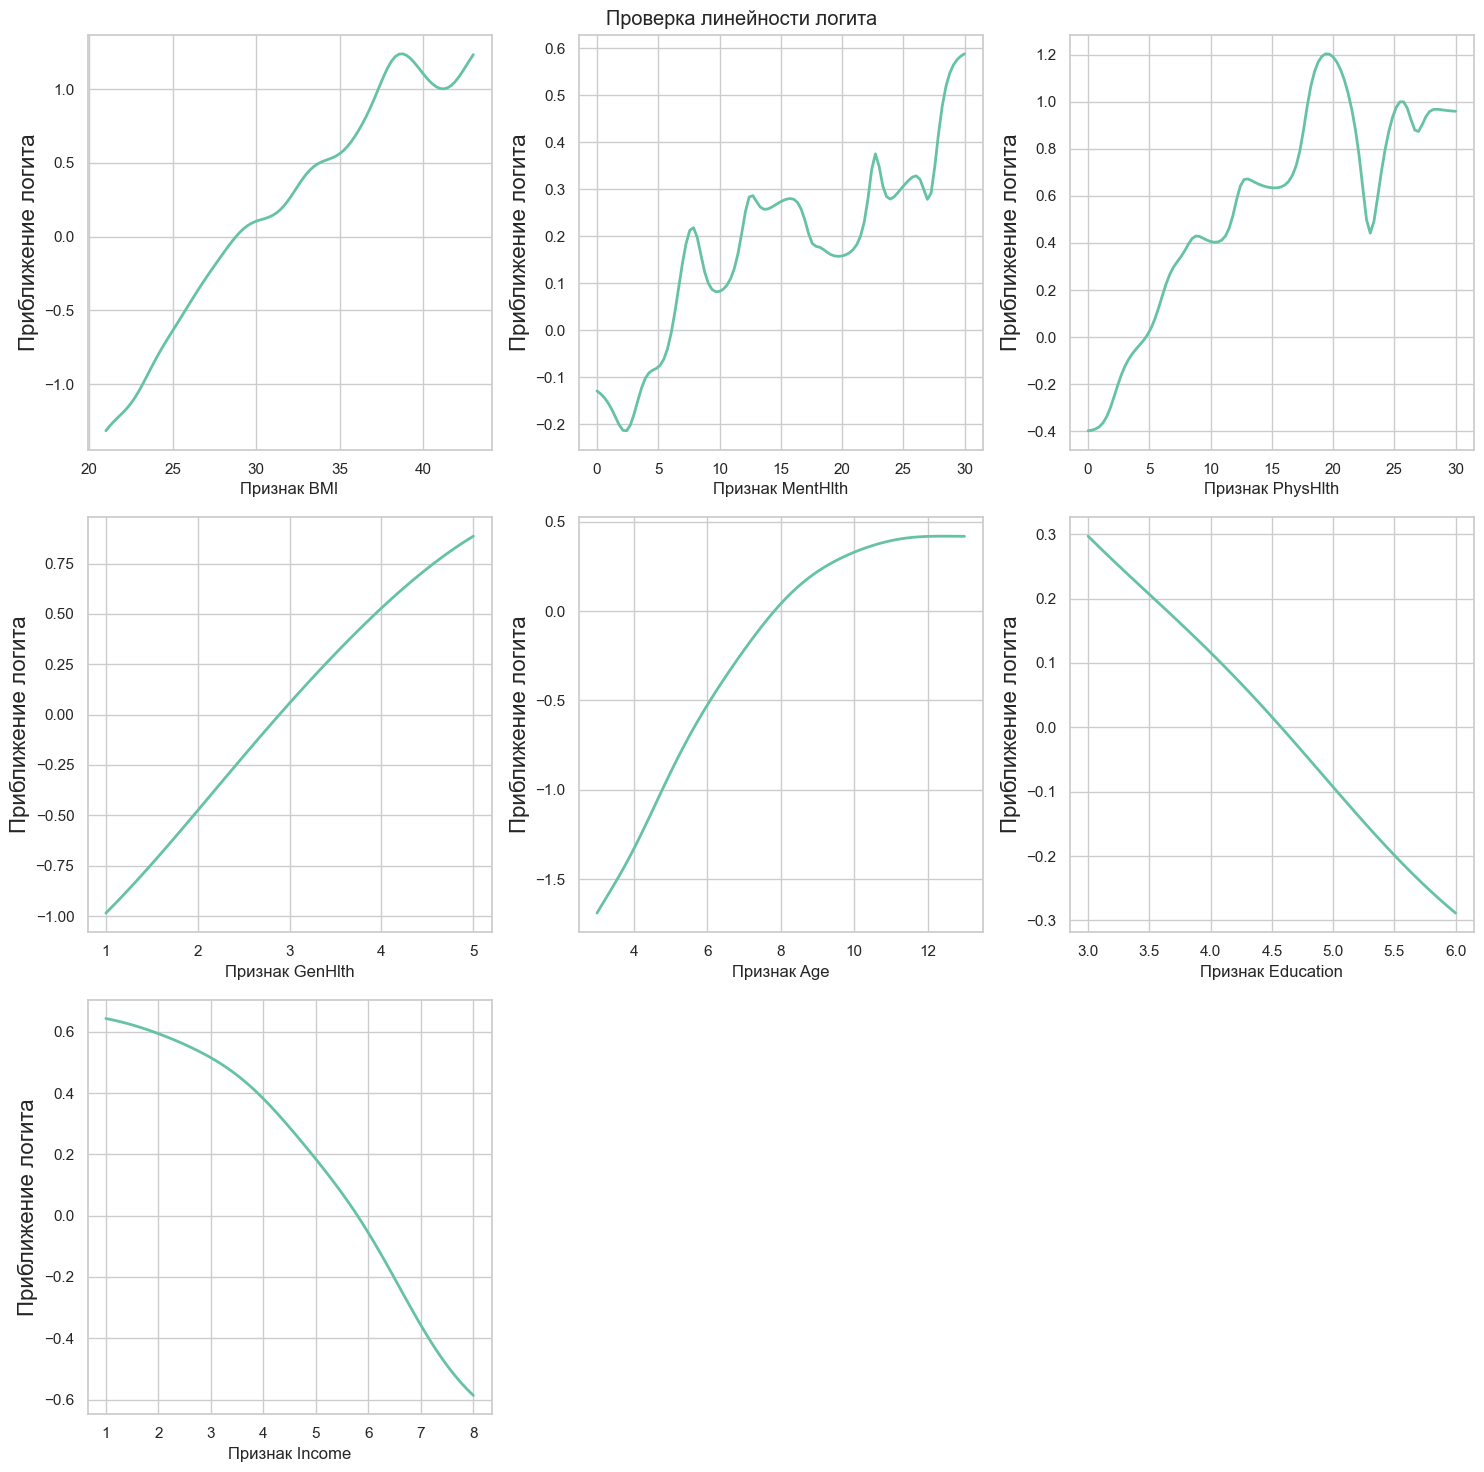

In [60]:
plot_logit_linearity_check(np.asarray(X_train[['BMI',
                                              'MentHlth', 'PhysHlth',
                                              'GenHlth', 'Age',
                                              'Education', 'Income']]), np.asarray(y_train),
                           ['BMI','MentHlth', 'PhysHlth',
                            'GenHlth', 'Age',
                            'Education', 'Income'], n_rows=3, figsize=(15,15))

Есть ли какая-то нелинейность по каким-либо признакам? Если да, попробуйте улучшить модель, рассмотрев преобразования признаков. Сравните полученную модель по качеству с предыдущими.

Достаточно простого решения, тратить много времени на подобный анализ признаков в данном случае не нужно.

Логит очень хорошо описывается прямой для признаков:
* `'GenHlth'`,
* `'Education'`

Виден характерный монотонный изгиб для признаков:
* `Age`
* `Income`
Для них добавим квадратичный признак


Признак `BMI` достаточно хорошо описывается, только  при больших значениях присутсвует шум, оставим без изменений

Признаки `MentHlth` и `PhysHlth` имееют большой шум, оставим эти признаки, как есть.

In [85]:
X_train_adv = X_train.copy()

X_test_adv = X_test.copy()

X_train_adv['Income_2'] = X_train_adv['Income'] ** 2
X_test_adv['Income_2'] = X_test_adv['Income'] ** 2

X_train_adv['GenHlth_2'] = X_train_adv['GenHlth'] ** 2
X_test_adv['GenHlth_2'] = X_test_adv['GenHlth'] ** 2

del X_train_adv['PhysHlth']
del X_test_adv['PhysHlth']



scaler = StandardScaler()
X_train_adv = scaler.fit_transform(X_train_adv)
X_test_adv = scaler.transform(X_test_adv)



model_adv = MyLogisticRegression(method='gd', learning_rate=0.37, max_iter=6000, tol=1e-8)
model_adv.fit(X_train_adv, y_train)

print((model_adv.predict(X_test_adv) == y_test).mean())

0.7267840724237924


<font color="green" size="5"><b>Исправления ниже</b></font>


Модель с новыми признаками имеет точность 0.7268, что больше, чем 0.725 у предыдущей модели. Предсказательная сила выросла

<font color="green" size="5"><b>Исправления выше</b></font>


**6.** Приведите интерпретацию полученных значений оценок коэффициентов относительно рассматриваемых данных в виде "*при изменении признака на 1 у.е. ...*". Мы хотим получить интерпретацию относительно исходных данных, поэтому для ответа на этот вопрос нужно рассматривать признаки *без стандартизации*. Согласуется ли эта интерпретация с вашими личными представлениями о природе данных?

Посмотрите примеры в ноутбуке с занятия. Необходимо привести интерпретацию для нескольких конкретных признаков, общее описание не будет зачтено.

<details>
<summary> ➡️ Если ранее обучили модель со стандартизацией признаков </summary>    
    Можно заново обучить модель без стандартизации признаков. Но можно этого и не делать, немного поправив коэффициенты обученной ранее модели (получатся те же коэффициенты после стандартизации). Подумайте, как именно.
</details>

In [88]:
model_st = MyLogisticRegression(method='gd', learning_rate=1e-3, max_iter=2000, tol=1e-7)
model_st.fit(X_train, y_train)
print((model_st.predict(X_test) == y_test).mean())

0.6854798783506613


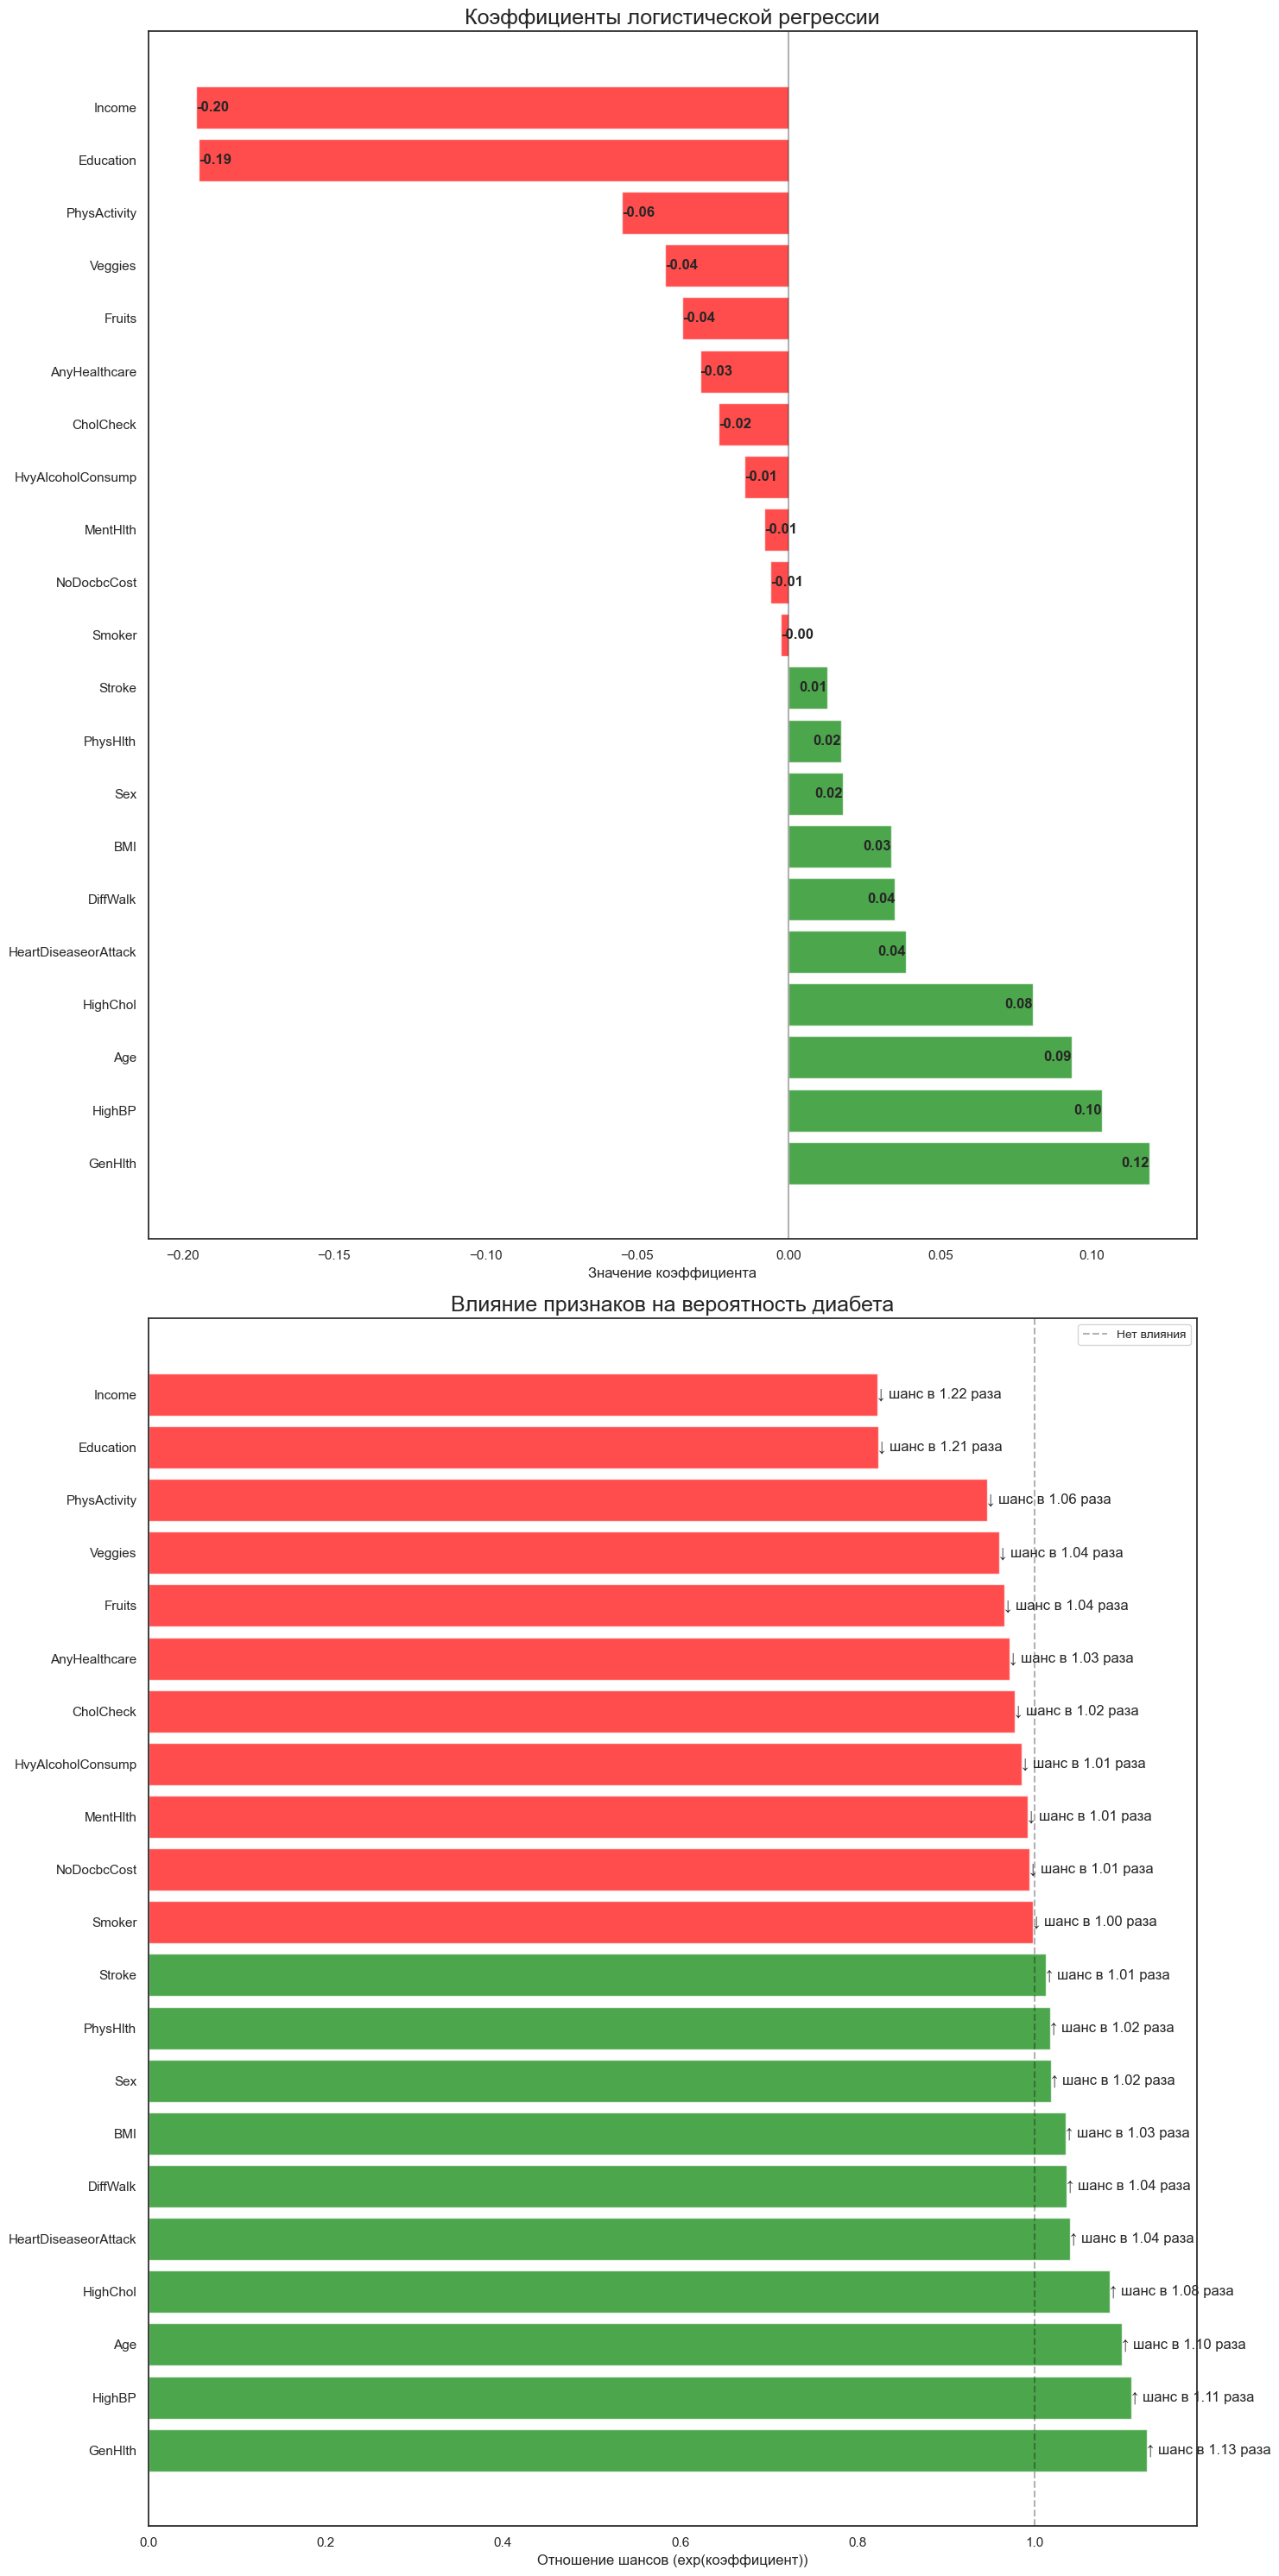

In [664]:
all_feature_names = X_train.columns


# Получаем коэффициенты для выбранных признаков
selected_coef = model_st.coef_
selected_odds = np.exp(selected_coef)

coef_plot_df = pd.DataFrame(
    {"Признак": all_feature_names, "Коэффициент": selected_coef, "Отношение_шансов": selected_odds}
).sort_values("Коэффициент", ascending=False)

with sns.axes_style("white"):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 30))

# Верхний график — коэффициенты
colors = ["green" if x > 0 else "red" for x in coef_plot_df["Коэффициент"]]
ax1.barh(coef_plot_df["Признак"], coef_plot_df["Коэффициент"], color=colors, alpha=0.7)
ax1.set_xlabel("Значение коэффициента")
ax1.set_title("Коэффициенты логистической регрессии", fontsize=18)
ax1.axvline(x=0, color="black", linestyle="-", alpha=0.3)
ax1.tick_params(axis="y")
ax1.tick_params(axis="x")

for coef_index, coef in enumerate(coef_plot_df["Коэффициент"]):
    ax1.text(
        coef,
        coef_index,
        f"{coef:.2f}",
        va="center",
        ha="right" if coef > 0 else "left",
        fontweight="bold",
    )

# Нижний график — отношения шансов
ax2.barh(coef_plot_df["Признак"], coef_plot_df["Отношение_шансов"], color=colors, alpha=0.7)
ax2.set_xlabel("Отношение шансов (exp(коэффициент))")
ax2.set_title("Влияние признаков на вероятность диабета", fontsize=18)
ax2.axvline(x=1, color="black", linestyle="--", alpha=0.3, label="Нет влияния")
ax2.tick_params(axis="y")
ax2.tick_params(axis="x")

for ind, ratio in enumerate(coef_plot_df["Отношение_шансов"]):
    if ratio > 1:
        interpretation = f"↑ шанс в {ratio:.2f} раза"
    else:
        interpretation = f"↓ шанс в {1/ratio:.2f} раза"
    ax2.text(ratio, ind, interpretation, va="center", ha="left")

ax2.legend(fontsize=10)
plt.tight_layout()
plt.show()

Сильнее всего влияет высокое давление, при увелчении GenHlth на 1, шанс диабета увеличивается на 1.13

Увеличение возраста на 1 увеличивает шанс диабета в 1.1 раз

Пол и курение почти не влияет

Сильнее всего уменьшает шанс диабета переход в следущую группу по доходу и по образованию (уменьшение в 1.22 и в 1.23 соответственно)

В общем и целом данные согласуются с моими представлениями о данных, единственное, не очевидно, что увеличение уровня образования на 1 уменьшает шанс в 1.22. В остальном, чем хуже здоровье и меньше активность, тем больше шанс диабета



**7.** Какие больше всего влияют на изменение вероятности класса 1? Согласуются ли эти выводы с вашими личными представлениями о природе данных?

Ответ на этот вопрос не следует из предыдущего, поскольку там мы рассматривали коэффициенты как величины, имеющие различные единицы измерения. Чтобы сравнить коэффициенты, нам потребуется стандартизировать признаки, тем самым обезразмерить их и соответствующие коэффициенты. 

<details>
<summary> ➡️ Если ранее обучили модель без стандартизации признаков </summary>    
    Стандартизацию можно сделать с помощью <code>StandardScaler()</code> и обучить модель логистической регрессии заново. Но можно этого и не делать, немного поправив коэффициенты обученной ранее модели (получатся те же коэффициенты после стандартизации). Подумайте, как именно.
</details>

In [665]:
model_st = MyLogisticRegression(method='gd', learning_rate=1e-2, max_iter=2000, tol=1e-7)
model_st.fit(X_train_adv, y_train)
print((model_st.predict(X_test_adv) == y_test).mean())

0.7232477544380791


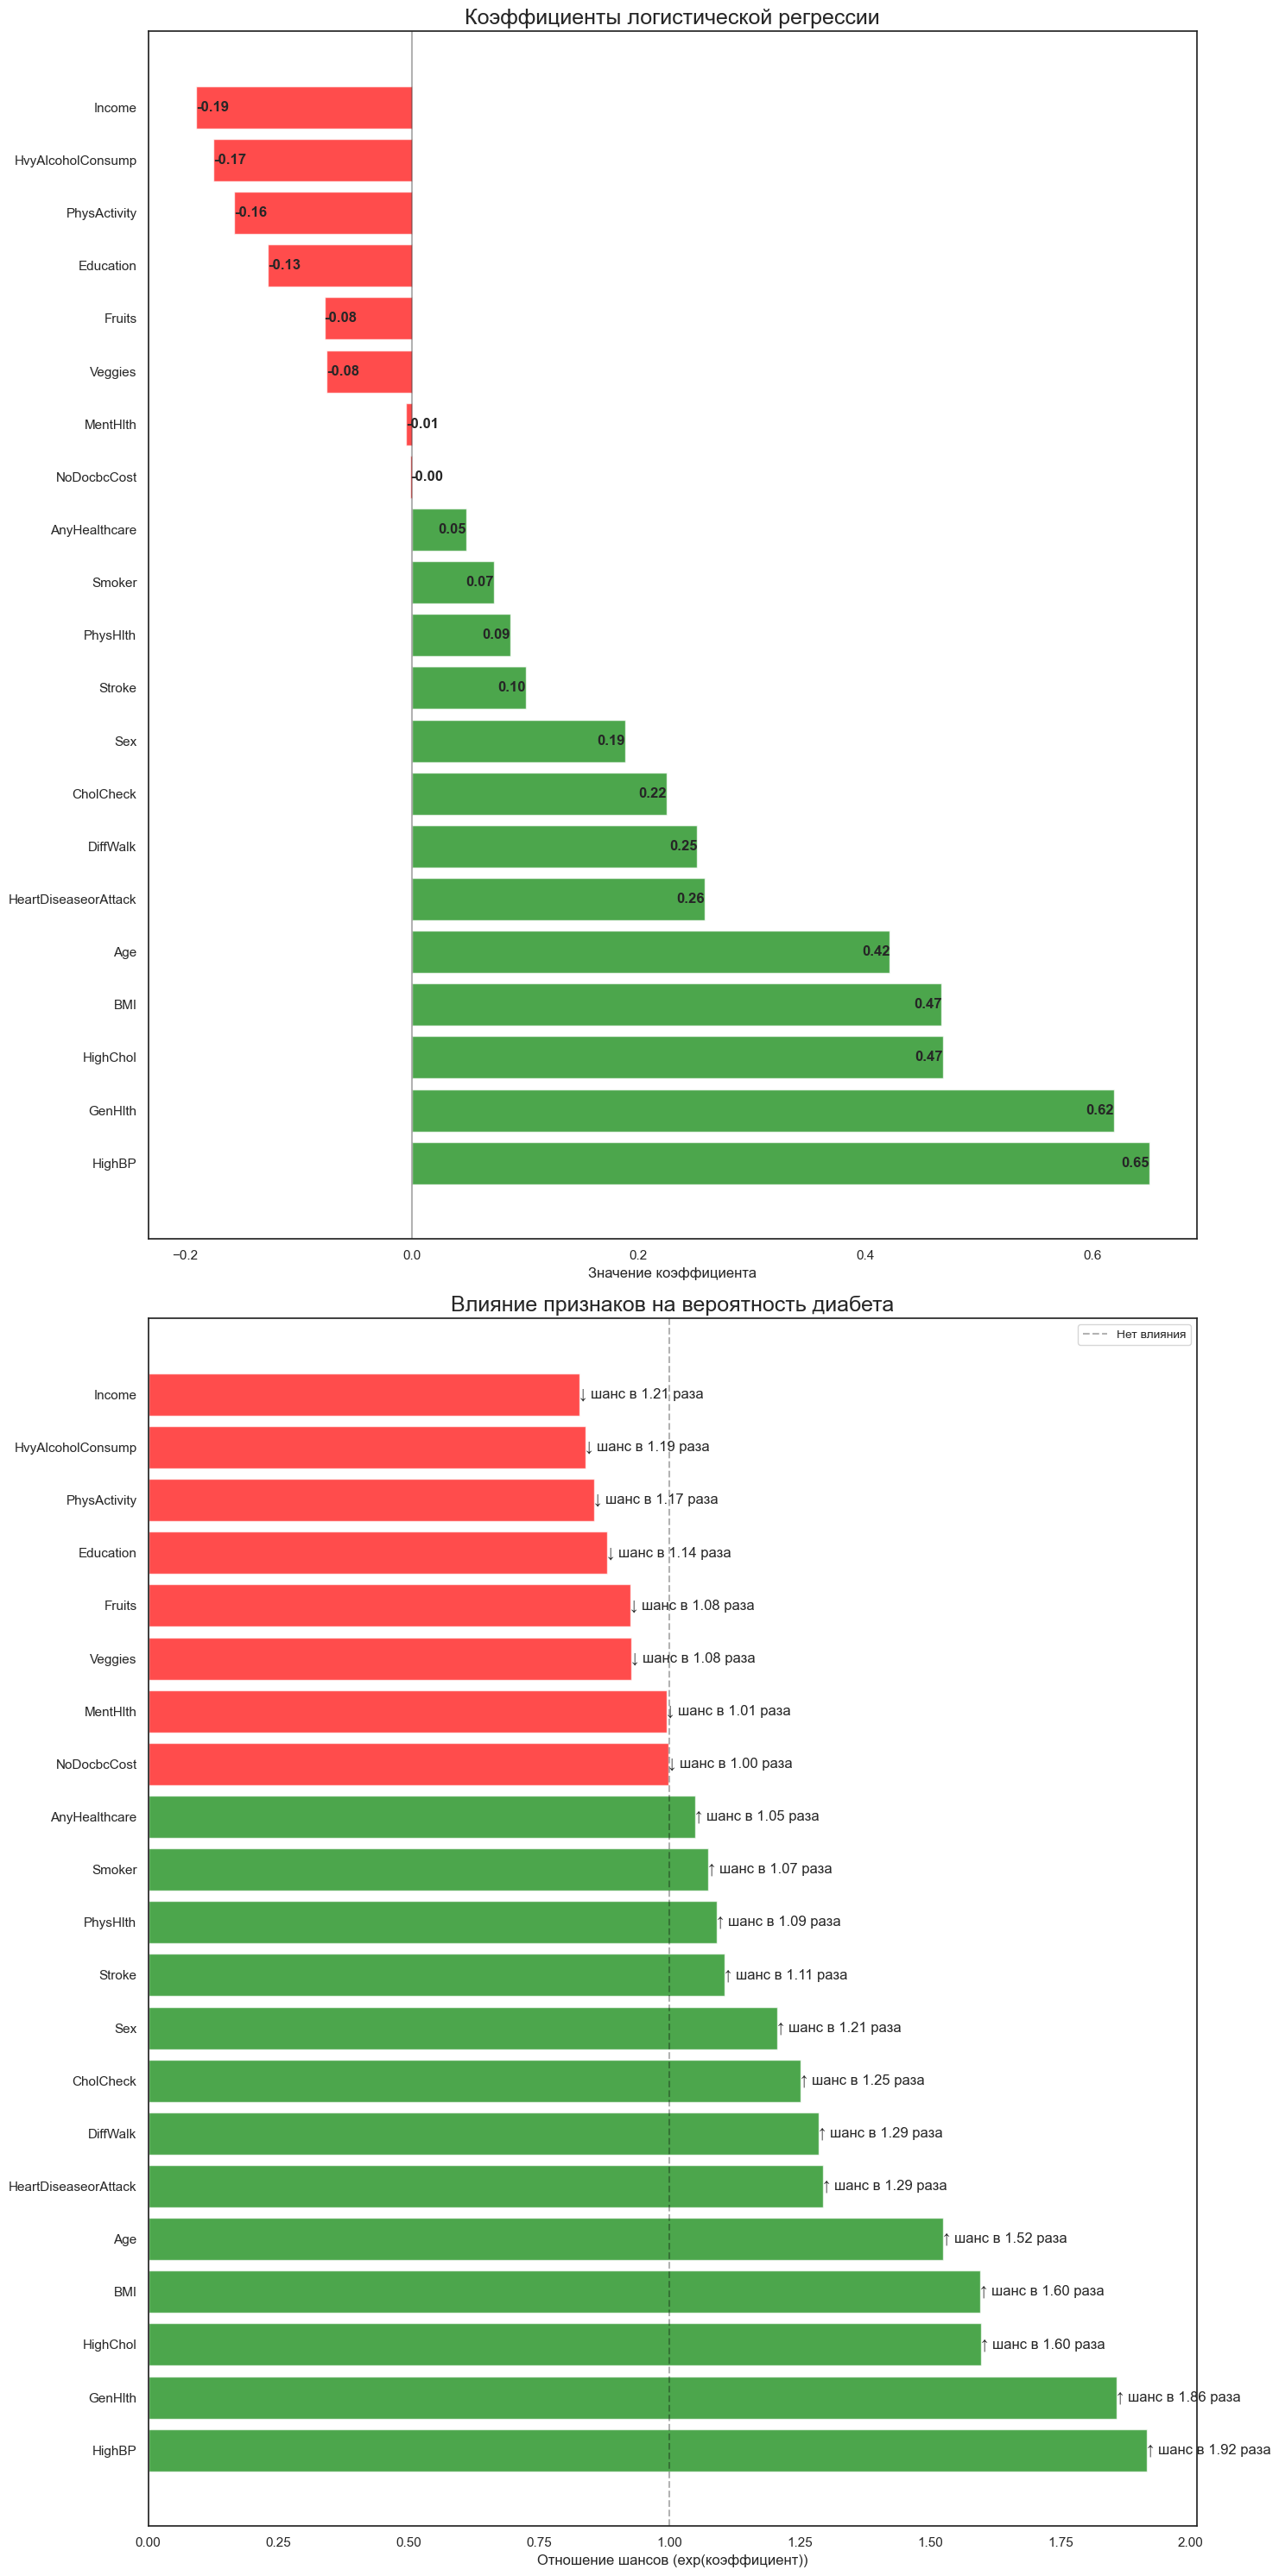

In [666]:
all_feature_names = X_train.columns


# Получаем коэффициенты для выбранных признаков
selected_coef = model_st.coef_
selected_odds = np.exp(selected_coef)

coef_plot_df = pd.DataFrame(
    {"Признак": all_feature_names, "Коэффициент": selected_coef, "Отношение_шансов": selected_odds}
).sort_values("Коэффициент", ascending=False)

with sns.axes_style("white"):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 30))

# Верхний график — коэффициенты
colors = ["green" if x > 0 else "red" for x in coef_plot_df["Коэффициент"]]
ax1.barh(coef_plot_df["Признак"], coef_plot_df["Коэффициент"], color=colors, alpha=0.7)
ax1.set_xlabel("Значение коэффициента")
ax1.set_title("Коэффициенты логистической регрессии", fontsize=18)
ax1.axvline(x=0, color="black", linestyle="-", alpha=0.3)
ax1.tick_params(axis="y")
ax1.tick_params(axis="x")

for coef_index, coef in enumerate(coef_plot_df["Коэффициент"]):
    ax1.text(
        coef,
        coef_index,
        f"{coef:.2f}",
        va="center",
        ha="right" if coef > 0 else "left",
        fontweight="bold",
    )

# Нижний график — отношения шансов
ax2.barh(coef_plot_df["Признак"], coef_plot_df["Отношение_шансов"], color=colors, alpha=0.7)
ax2.set_xlabel("Отношение шансов (exp(коэффициент))")
ax2.set_title("Влияние признаков на вероятность диабета", fontsize=18)
ax2.axvline(x=1, color="black", linestyle="--", alpha=0.3, label="Нет влияния")
ax2.tick_params(axis="y")
ax2.tick_params(axis="x")

for ind, ratio in enumerate(coef_plot_df["Отношение_шансов"]):
    if ratio > 1:
        interpretation = f"↑ шанс в {ratio:.2f} раза"
    else:
        interpretation = f"↓ шанс в {1/ratio:.2f} раза"
    ax2.text(ratio, ind, interpretation, va="center", ha="left")

ax2.legend(fontsize=10)
plt.tight_layout()
plt.show()

Без относительно размерности:

Больше всего влияет `GenHlth`, `HighBP`, `HighChol`:
Безразмерное увеличение шансов равно соотсветвенно: 1.86, 1.92, 1.60

**8. Вывод:**

Получили, достаточно хорошую оценку модели, по сравнению с бейзлайн моделью. 0.72 vs 0.49

Модель логистической регрессии хорошо может прогнозировать класс объекта в модели классификации. При этом необходимо проводить нормализацию и подбирать правильный tol и learning_rate

*Надеемся, что ты все успел, и тебе понравилось! Ждем тебя на следующей лекции!*

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для ВвАД